# ASD-GNN — Results

Every number below is read from `results/runs/*.json`. **This notebook contains no
pipeline logic**: it fits nothing, trains nothing, and computes no connectivity. If a
number here is wrong, the fix belongs in `src/asdgnn/`, not in a cell.

To populate the results directory:

```bash
make smoke                 # synthetic cohort, ~1 minute, no download
# or the real thing:
make data features leak sanity baselines graphs tables figures
```

**Contents**
1. Cohort and QC
2. Leakage and sanity evidence
3. Main results table
4. k-fold vs LOSO — the generalisation gap
5. Per-site behaviour under LOSO
6. ROC / PR curves
7. Statistical comparisons
8. Explainability
9. What to check before believing any of this

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RUNS, FIGS, TABLES, QC = (ROOT / p for p in
                          ("results/runs", "results/figures", "results/tables", "results/qc"))

pd.set_option("display.width", 160, "display.max_columns", 40)


def load_json(path, default=None):
    path = Path(path)
    return json.loads(path.read_text()) if path.exists() else default


def show_fig(name, caption=""):
    p = FIGS / name
    if p.exists():
        if caption:
            display(Markdown(f"**{caption}**"))
        display(Image(filename=str(p)))
    else:
        display(Markdown(f"_missing figure `{name}` — run `make figures`_"))


blobs = [json.loads(p.read_text()) for p in sorted(RUNS.glob("*.json"))]
print(f"{len(blobs)} runs in {RUNS}")
if not blobs:
    raise SystemExit("no runs — run `make smoke` first")

36 runs in /Users/amartyapanigrahi/Desktop/PEC/Semester 7/Major Project/asd-gnn/results/runs


## 1. Cohort and QC

`results/qc/cohort.json` is written by `data/phenotype.py`, `results/qc/dropped.json` by
the QC filter. Together they are the paper's participant flow diagram.

In [2]:
cohort = load_json(QC / "cohort.json", {})
if cohort:
    display(Markdown(
        f"**N = {cohort['n_subjects']}**  ·  ASD {cohort['n_asd']} / TC {cohort['n_tc']}  ·  "
        f"{cohort['n_sites']} sites  ·  {cohort['male_fraction']:.0%} male  ·  "
        f"age {cohort['age']['min']:.1f}–{cohort['age']['max']:.1f} "
        f"(mean {cohort['age']['mean']:.1f})"
    ))
    display(pd.DataFrame(cohort["per_site"]).set_index("SITE_ID").round(3))

    fd = cohort["mean_fd_by_group"]
    display(Markdown(
        f"Head motion (mean FD): ASD {fd['asd']:.3f} vs TC {fd['tc']:.3f}. "
        "A group difference here is a confound the Discussion must address — motion "
        "correlates with both diagnosis and connectivity."
    ))
else:
    display(Markdown("_no cohort report — run `scripts/01_build_features.py`_"))

**N = 871**  ·  ASD 403 / TC 468  ·  20 sites  ·  83% male  ·  age 6.5–58.0 (mean 16.9)

,n,n_asd,male_frac,age_mean,mean_fd,n_tc
SITE_ID,,,,,,
CALTECH,15,5,0.667,26.787,0.065,10
CMU,11,6,0.636,26.818,0.254,5
KKI,33,12,0.727,10.314,0.118,21
LEUVEN_1,28,14,1.000,22.429,0.079,14
LEUVEN_2,28,12,0.750,14.171,0.102,16
MAX_MUN,46,19,0.913,26.500,0.109,27
NYU,172,74,0.791,15.327,0.069,98
OHSU,25,12,1.000,10.810,0.097,13
OLIN,28,14,0.821,17.036,0.181,14


Head motion (mean FD): ASD 0.126 vs TC 0.094. A group difference here is a confound the Discussion must address — motion correlates with both diagnosis and connectivity.

In [3]:
dropped = load_json(QC / "dropped.json", {})
if dropped:
    reasons = pd.Series(dropped["dropped_subjects"]).str.replace(r"\(.*\)", "", regex=True)
    display(Markdown(
        f"Kept **{dropped['n_out']} / {dropped['n_in']}** subjects; "
        f"ROIs {dropped['n_rois_in']} → {dropped['n_rois_out']} "
        f"({len(dropped['dropped_rois'])} constant parcels dropped globally)."
    ))
    if len(reasons):
        display(reasons.value_counts().rename("n subjects dropped").to_frame())
else:
    display(Markdown("_no QC drop log (expected on the synthetic cohort)_"))

Kept **871 / 871** subjects; ROIs 200 → 179 (21 constant parcels dropped globally).

## 2. Leakage and sanity evidence

Nothing below section 3 means anything unless these pass. The label-shuffle check is the
single most valuable number in the project: run the **full** pipeline on permuted labels
and balanced accuracy must land at chance. Anything meaningfully above 0.5 is leakage,
and the correct response is to stop and find it.

In [4]:
sanity = load_json(QC / "sanity.json", {})
if sanity:
    rows = []
    for name, c in sanity.items():
        rows.append({
            "check": name,
            "bal_acc": c.get("bal_acc"),
            "status": {True: "PASS", False: "FAIL"}.get(c.get("pass"), "info"),
            "note": c.get("note") or c.get("expected") or "",
        })
    display(pd.DataFrame(rows).set_index("check").round(3))

    site = sanity.get("site_control", {}).get("bal_acc")
    if site is not None:
        display(Markdown(
            f"**Site-prediction control: {site:.3f}.** This is how strongly the features "
            "encode acquisition site rather than biology, and it is the number to cite "
            "when arguing that k-fold CV over-states real-world performance."
        ))
    failed = [k for k, c in sanity.items() if c.get("pass") is False]
    if failed:
        display(Markdown(f"### ⚠️ FAILED: {failed} — do not report anything below."))
else:
    display(Markdown("_no sanity report — run `python scripts/02_run_experiment.py --sanity`_"))

,bal_acc,status,note
check,,,
label_shuffle,0.525,PASS,~0.50
real_labels,0.633,info,"real labels beat shuffled, as expected"
sex_control,0.579,info,features should carry SOME real signal; chance...
site_control,0.673,info,quantifies the site confound — cite this numbe...
connectivity_fit_size,NaN,PASS,
mean_node_degree,NaN,PASS,a dense graph makes message passing a global a...
random_node_features,0.500,info,a large drop is expected; no drop means the mo...
empty_graph_ablation,0.511,info,edge-free control — the gap quantifies what to...


**Site-prediction control: 0.673.** This is how strongly the features encode acquisition site rather than biology, and it is the number to cite when arguing that k-fold CV over-states real-world performance.

## 3. Main results table

Balanced accuracy is the primary metric. Accuracy is reported because the literature
does, but a mildly imbalanced cohort plus LOSO folds with wild per-site class ratios
makes raw accuracy misleading.

In [5]:
from asdgnn.viz.tables import load_runs, main_table, protocol_comparison

df = load_runs(RUNS)
for protocol in sorted(df["protocol"].dropna().unique()):
    display(Markdown(f"### {protocol}"))
    display(main_table(df, protocol))

### kfold

,model,conn,atlas,harmonize,unseen_site,bal_acc,acc,auc,sens,spec
0,svm,correlation,cc200,none,passthrough,0.674 ± 0.060,0.675 ± 0.061,0.711 ± 0.063,0.662 ± 0.083,0.686 ± 0.089
1,mlp,correlation,cc200,none,passthrough,0.666 ± 0.037,0.669 ± 0.038,0.734 ± 0.046,0.625 ± 0.074,0.707 ± 0.081
2,braincnn,correlation,cc200,none,passthrough,0.658 ± 0.077,0.665 ± 0.069,0.716 ± 0.075,0.566 ± 0.202,0.750 ± 0.087
3,svm,correlation,cc200,combat,passthrough,0.646 ± 0.040,0.648 ± 0.040,0.709 ± 0.069,0.625 ± 0.091,0.667 ± 0.087
4,ridge,correlation,cc200,none,passthrough,0.642 ± 0.067,0.643 ± 0.068,0.677 ± 0.075,0.623 ± 0.074,0.660 ± 0.085
5,svm,tangent,cc200,none,passthrough,0.626 ± 0.076,0.630 ± 0.077,0.678 ± 0.086,0.568 ± 0.081,0.684 ± 0.095
6,rf,correlation,cc200,none,passthrough,0.622 ± 0.026,0.630 ± 0.026,0.682 ± 0.046,0.507 ± 0.071,0.737 ± 0.073
7,gcn,correlation,cc200,none,passthrough,0.600 ± 0.053,0.601 ± 0.059,0.646 ± 0.070,0.604 ± 0.186,0.596 ± 0.216
8,hybrid,correlation,cc200,none,n/a,0.598 ± 0.037,0.600 ± 0.036,0.636 ± 0.058,0.559 ± 0.126,0.637 ± 0.107
9,cheb,correlation,cc200,none,passthrough,0.597 ± 0.071,0.600 ± 0.070,0.655 ± 0.060,0.568 ± 0.209,0.627 ± 0.200


### loso

,model,conn,atlas,harmonize,unseen_site,bal_acc,acc,auc,sens,spec
0,mlp,correlation,cc200,none,passthrough,0.643 ± 0.085,0.649 ± 0.087,0.704 ± 0.096,0.585 ± 0.156,0.701 ± 0.154
1,braincnn,correlation,cc200,none,passthrough,0.639 ± 0.087,0.648 ± 0.085,0.716 ± 0.100,0.558 ± 0.270,0.720 ± 0.190
2,svm,correlation,cc200,none,passthrough,0.631 ± 0.077,0.637 ± 0.078,0.679 ± 0.098,0.591 ± 0.137,0.671 ± 0.116
3,rf,correlation,cc200,none,passthrough,0.625 ± 0.087,0.623 ± 0.096,0.699 ± 0.096,0.498 ± 0.244,0.751 ± 0.219
4,svm,tangent,cc200,none,passthrough,0.608 ± 0.083,0.605 ± 0.084,0.671 ± 0.146,0.599 ± 0.166,0.617 ± 0.166
5,cheb,correlation,cc200,none,passthrough,0.593 ± 0.070,0.599 ± 0.089,0.656 ± 0.074,0.600 ± 0.272,0.586 ± 0.285
6,sage,correlation,cc200,none,passthrough,0.590 ± 0.065,0.596 ± 0.080,0.643 ± 0.058,0.637 ± 0.231,0.543 ± 0.265
7,svm,correlation,cc200,combat,reference,0.590 ± 0.045,0.615 ± 0.063,0.662 ± 0.107,0.239 ± 0.077,0.941 ± 0.051
8,ridge,correlation,cc200,none,passthrough,0.589 ± 0.049,0.588 ± 0.042,0.643 ± 0.089,0.540 ± 0.119,0.638 ± 0.099
9,svm,correlation,cc200,combat,transductive,0.588 ± 0.046,0.615 ± 0.054,0.664 ± 0.113,0.241 ± 0.065,0.936 ± 0.055


## 4. k-fold vs LOSO — the generalisation gap

This is the headline scientific figure, and the honest one. Within-site cross-validation
lets a model exploit site-specific signal; leave-one-site-out does not. Points below the
diagonal are the real story about whether any of this transfers to a new scanner.

protocol,model,conn_kind,atlas,harmonize,unseen_site,kfold,loso,drop
16,svm,correlation,cc200,none,passthrough,0.674,0.631,0.043
6,mlp,correlation,cc200,none,passthrough,0.666,0.643,0.023
0,braincnn,correlation,cc200,none,passthrough,0.658,0.639,0.019
13,svm,correlation,cc200,combat,passthrough,0.646,0.500,0.146
11,ridge,correlation,cc200,none,passthrough,0.642,0.589,0.053
18,svm,tangent,cc200,none,passthrough,0.626,0.608,0.018
10,rf,correlation,cc200,none,passthrough,0.622,0.625,-0.003
3,gcn,correlation,cc200,none,passthrough,0.600,0.560,0.040
5,hybrid,correlation,cc200,none,n/a,0.598,0.569,0.029
1,cheb,correlation,cc200,none,passthrough,0.597,0.593,0.004


Mean k-fold → LOSO drop: **0.022** balanced accuracy. A drop of this kind is the expected, publishable result — a model showing *no* drop is more likely to be leaking than to be good.

**Within-site vs cross-site generalisation**

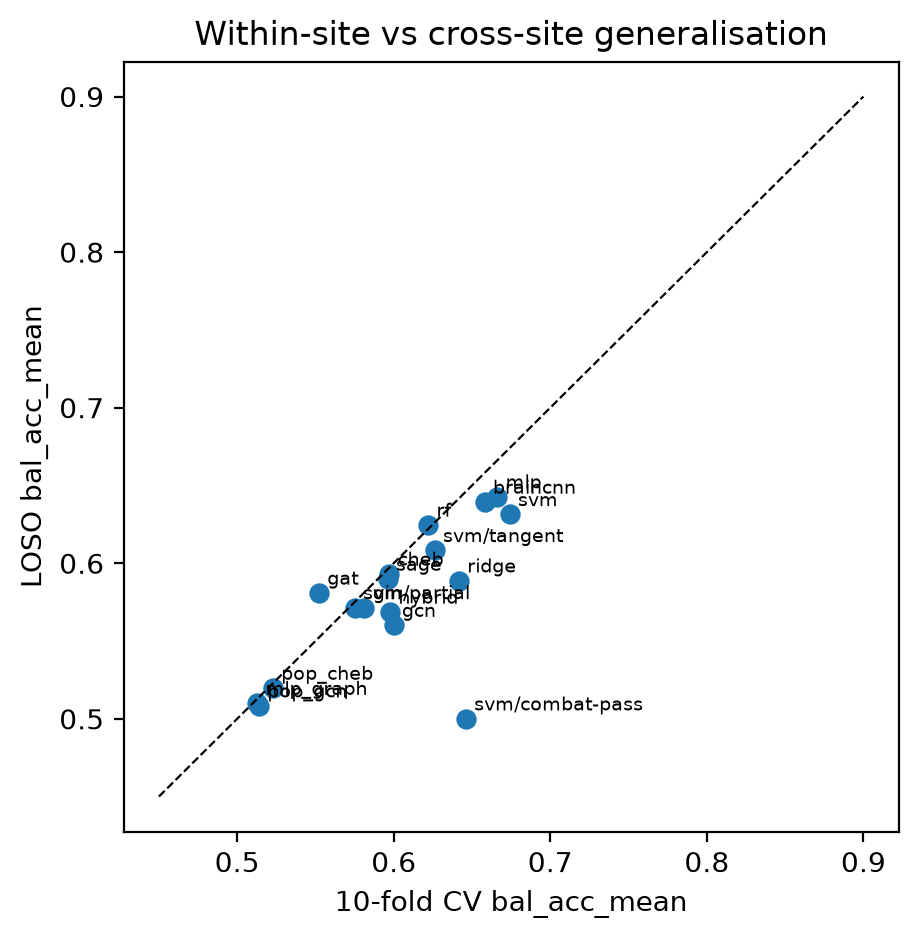

In [6]:
comp = protocol_comparison(df)
display(comp.round(3))
if "drop" in comp:
    display(Markdown(
        f"Mean k-fold → LOSO drop: **{comp['drop'].mean():.3f}** balanced accuracy. "
        "A drop of this kind is the expected, publishable result — a model showing *no* "
        "drop is more likely to be leaking than to be good."
    ))
show_fig("kfold_vs_loso.png", "Within-site vs cross-site generalisation")

## 5. Per-site behaviour under LOSO

Per-site variance is large and driven mostly by site size. Report per-site n alongside
per-site scores; a site with 12 subjects contributes noise, not evidence. Sites below the
`min_site_n` threshold are flagged `underpowered` in the run JSON.

### cheb  (underpowered: ['CALTECH', 'CMU'])

,n,n_pos,bal_acc,auc
site,,,,
NYU,172,74,0.630,0.701
UM_1,86,34,0.626,0.656
USM,67,43,0.639,0.729
UCLA_1,64,37,0.643,0.727
PITT,50,24,0.603,0.623
MAX_MUN,46,19,0.542,0.528
TRINITY,44,19,0.531,0.556
YALE,41,22,0.751,0.789
UM_2,34,13,0.647,0.685


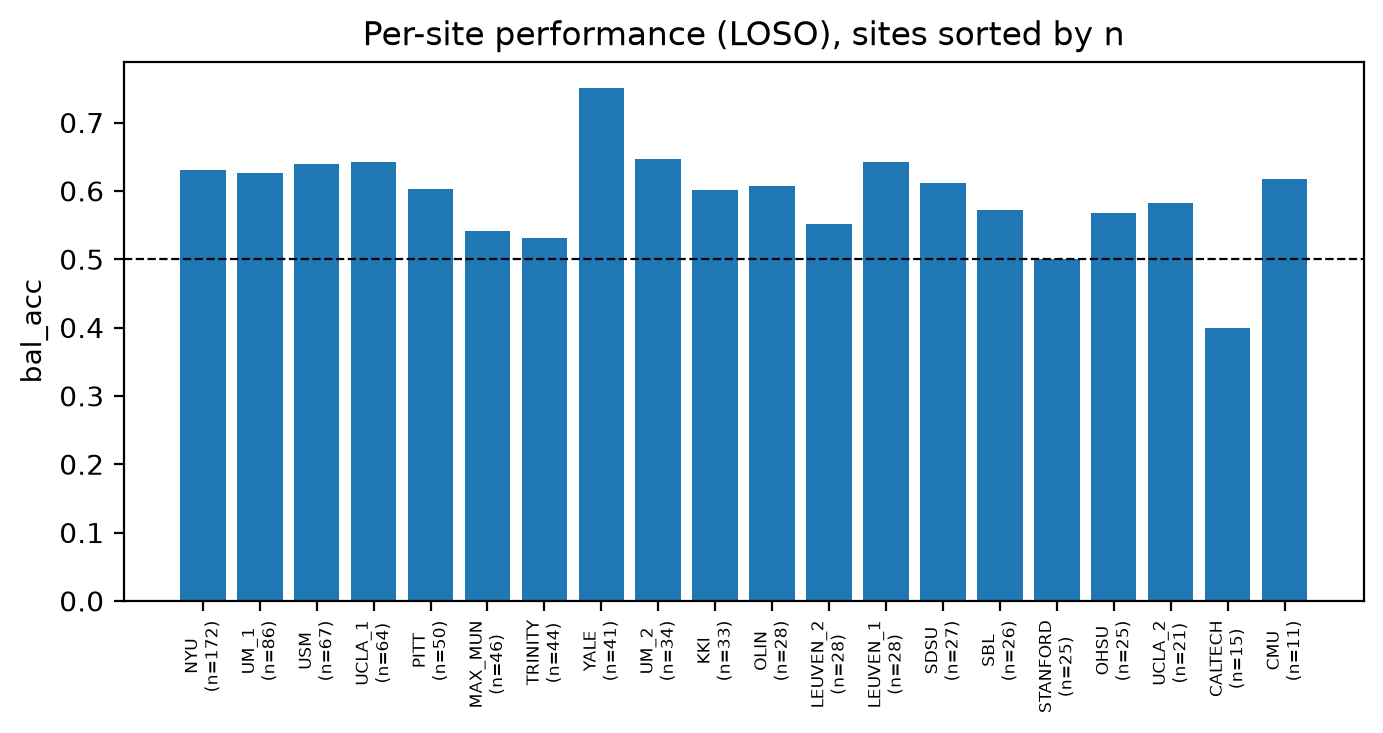

### svm  (underpowered: ['CALTECH', 'CMU'])

,n,n_pos,bal_acc,auc
site,,,,
NYU,172,74,0.678,0.700
UM_1,86,34,0.602,0.653
USM,67,43,0.701,0.814
UCLA_1,64,37,0.639,0.672
PITT,50,24,0.635,0.652
MAX_MUN,46,19,0.612,0.593
TRINITY,44,19,0.608,0.608
YALE,41,22,0.585,0.699
UM_2,34,13,0.679,0.795


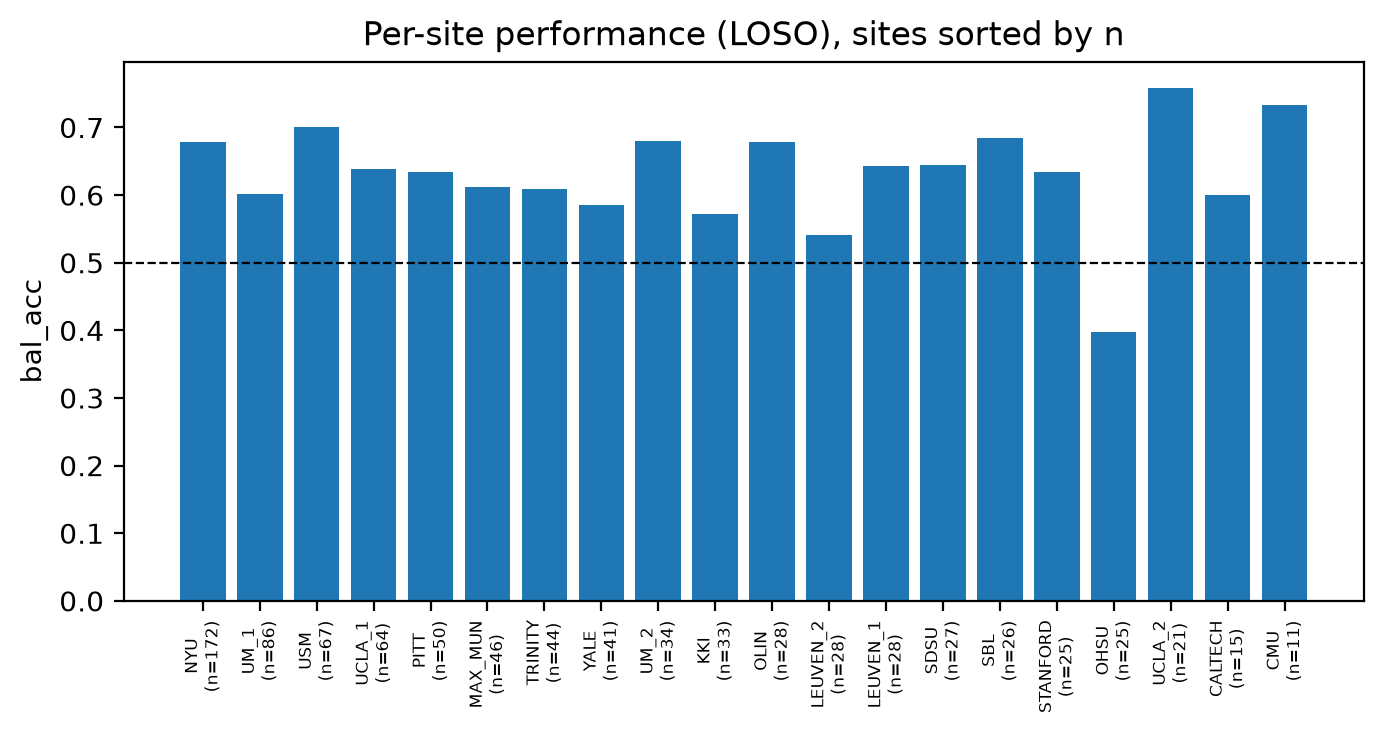

### gat  (underpowered: ['CALTECH', 'CMU'])

,n,n_pos,bal_acc,auc
site,,,,
NYU,172,74,0.620,0.674
UM_1,86,34,0.555,0.691
USM,67,43,0.509,0.760
UCLA_1,64,37,0.581,0.670
PITT,50,24,0.566,0.628
MAX_MUN,46,19,0.519,0.505
TRINITY,44,19,0.536,0.509
YALE,41,22,0.774,0.782
UM_2,34,13,0.656,0.685


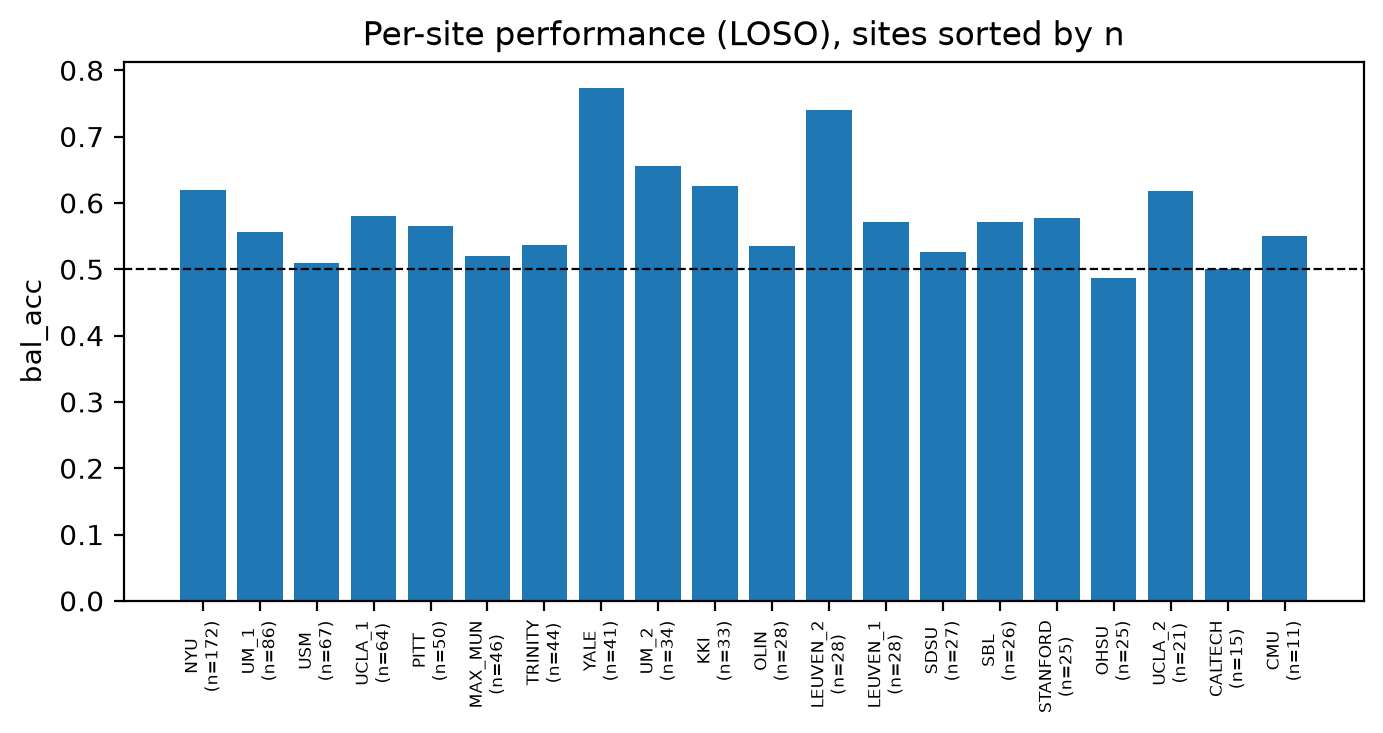

### svm  (underpowered: ['CALTECH', 'CMU'])

,n,n_pos,bal_acc,auc
site,,,,
NYU,172,74,0.5,0.688
UM_1,86,34,0.5,0.657
USM,67,43,0.5,0.749
UCLA_1,64,37,0.5,0.633
PITT,50,24,0.5,0.649
MAX_MUN,46,19,0.5,0.450
TRINITY,44,19,0.5,0.615
YALE,41,22,0.5,0.672
UM_2,34,13,0.5,0.769


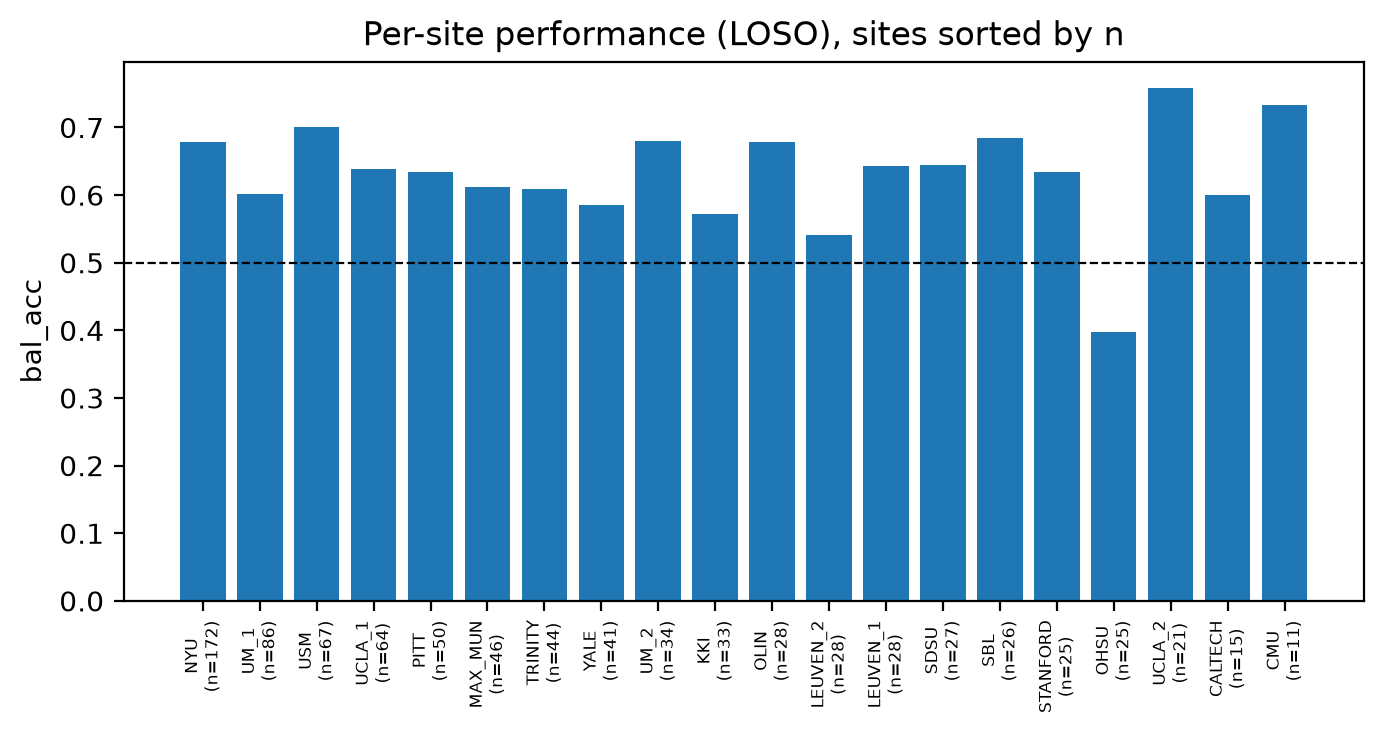

### sage  (underpowered: ['CALTECH', 'CMU'])

,n,n_pos,bal_acc,auc
site,,,,
NYU,172,74,0.666,0.667
UM_1,86,34,0.597,0.631
USM,67,43,0.528,0.697
UCLA_1,64,37,0.614,0.638
PITT,50,24,0.697,0.726
MAX_MUN,46,19,0.525,0.550
TRINITY,44,19,0.587,0.621
YALE,41,22,0.581,0.660
UM_2,34,13,0.670,0.736


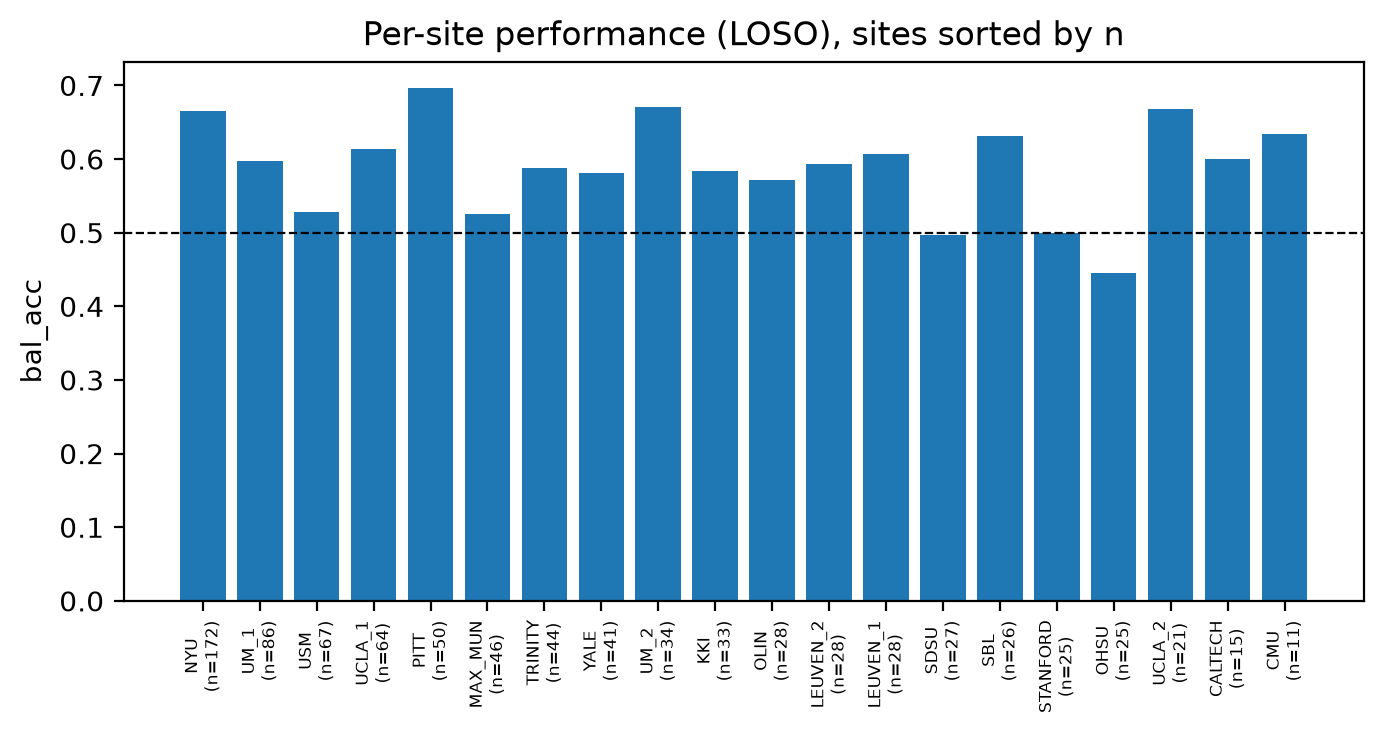

### gcn  (underpowered: ['CALTECH', 'CMU'])

,n,n_pos,bal_acc,auc
site,,,,
NYU,172,74,0.598,0.659
UM_1,86,34,0.627,0.675
USM,67,43,0.563,0.665
UCLA_1,64,37,0.553,0.672
PITT,50,24,0.551,0.587
MAX_MUN,46,19,0.426,0.454
TRINITY,44,19,0.515,0.600
YALE,41,22,0.500,0.605
UM_2,34,13,0.593,0.597


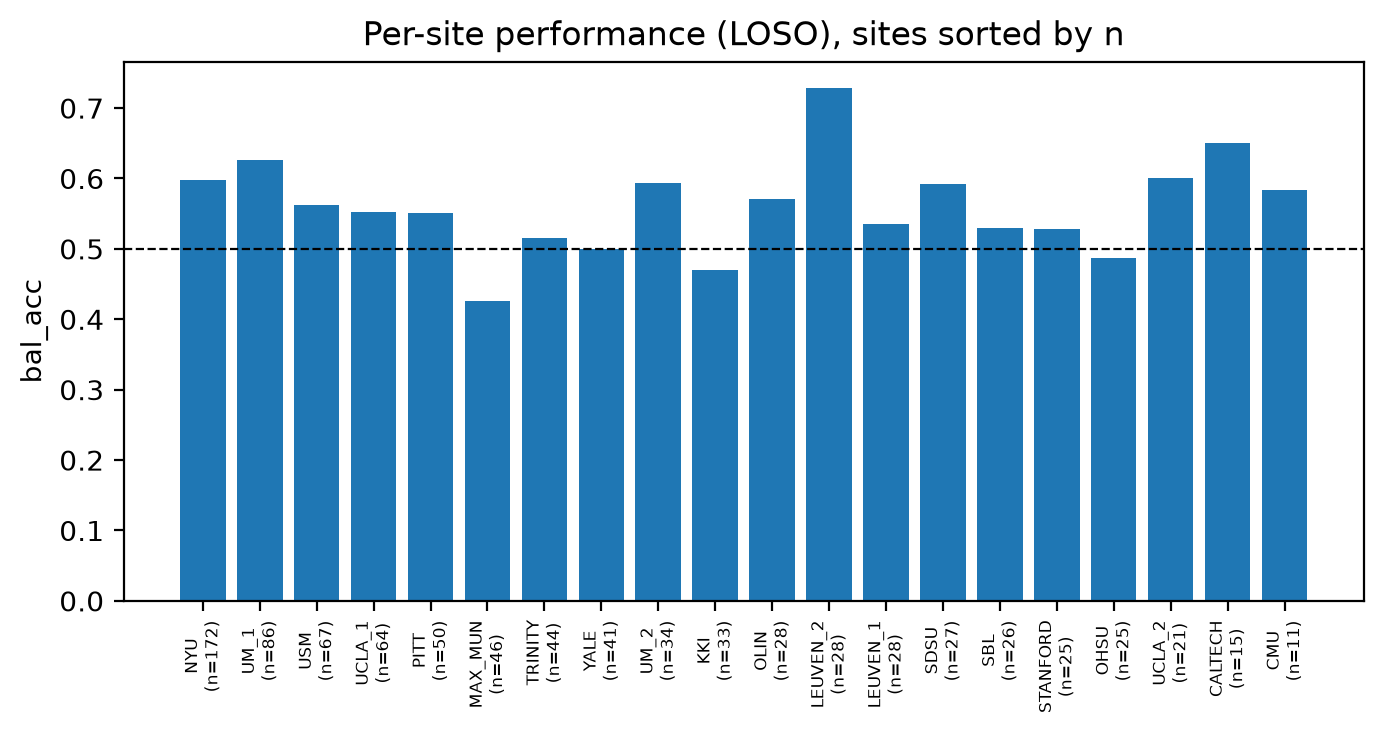

### ridge  (underpowered: ['CALTECH', 'CMU'])

,n,n_pos,bal_acc,auc
site,,,,
NYU,172,74,0.581,0.631
UM_1,86,34,0.573,0.640
USM,67,43,0.675,0.766
UCLA_1,64,37,0.626,0.671
PITT,50,24,0.596,0.628
MAX_MUN,46,19,0.541,0.622
TRINITY,44,19,0.623,0.568
YALE,41,22,0.562,0.589
UM_2,34,13,0.670,0.733


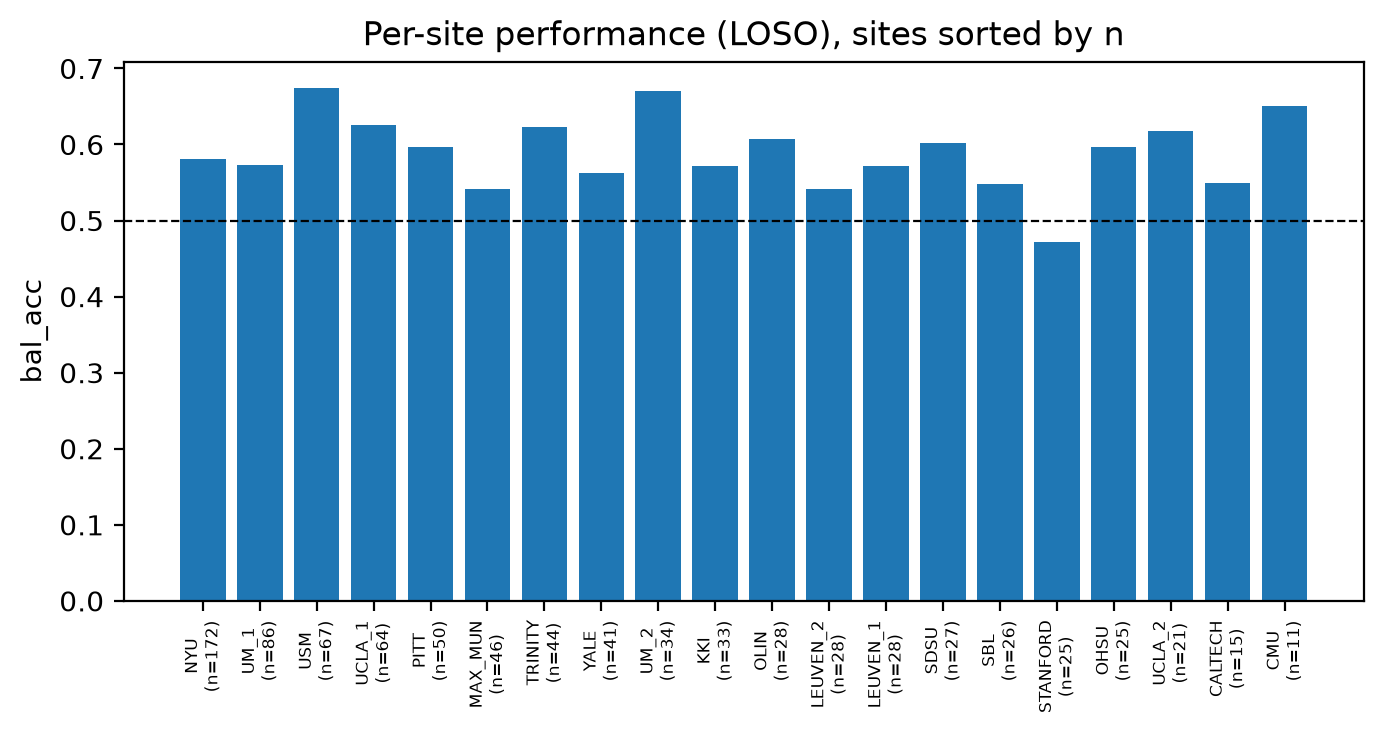

### pop_gcn  (underpowered: ['CALTECH', 'CMU'])

,n,n_pos,bal_acc,auc
site,,,,
NYU,172,74,0.500,0.633
UM_1,86,34,0.628,0.679
USM,67,43,0.500,0.636
UCLA_1,64,37,0.539,0.677
PITT,50,24,0.500,0.699
MAX_MUN,46,19,0.500,0.554
TRINITY,44,19,0.500,0.505
YALE,41,22,0.500,0.627
UM_2,34,13,0.500,0.626


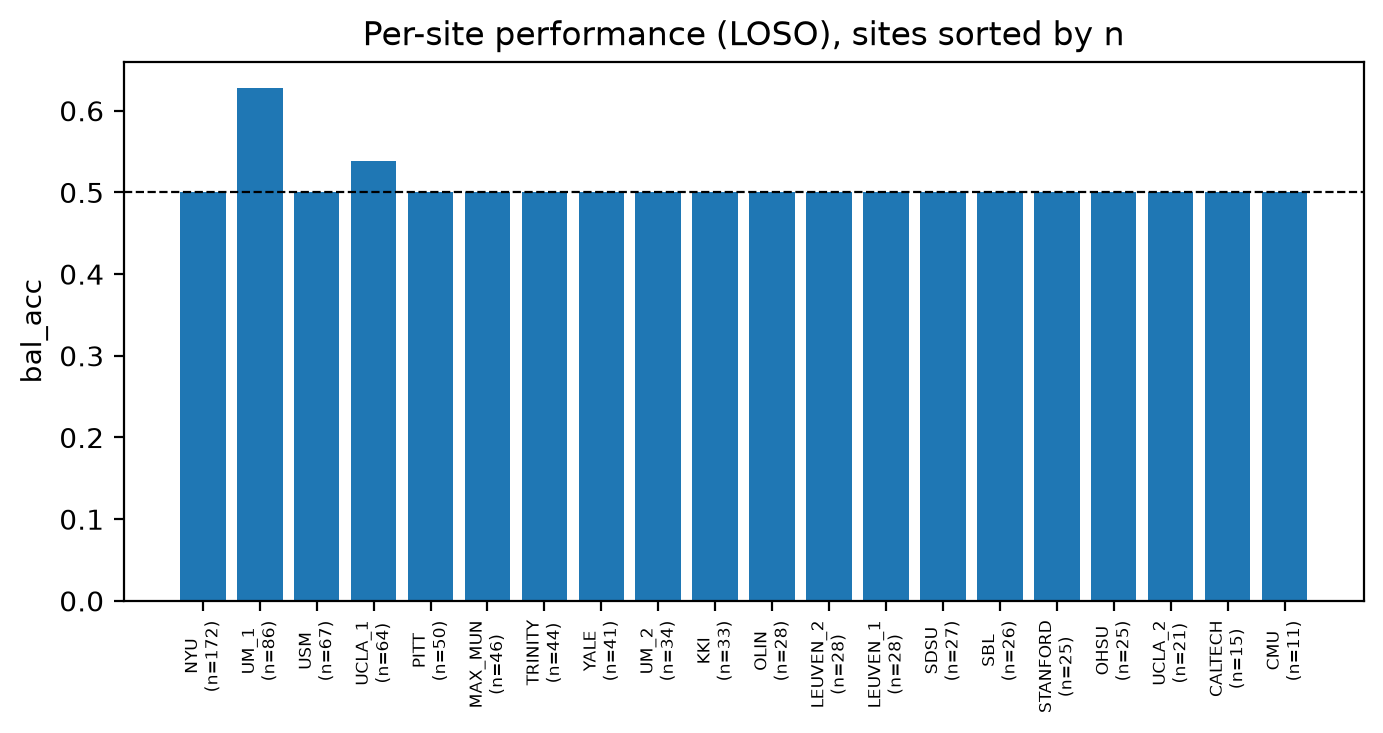

### braincnn  (underpowered: ['CALTECH', 'CMU'])

,n,n_pos,bal_acc,auc
site,,,,
NYU,172,74,0.746,0.789
UM_1,86,34,0.643,0.707
USM,67,43,0.754,0.829
UCLA_1,64,37,0.675,0.723
PITT,50,24,0.683,0.740
MAX_MUN,46,19,0.589,0.544
TRINITY,44,19,0.589,0.654
YALE,41,22,0.728,0.787
UM_2,34,13,0.742,0.850


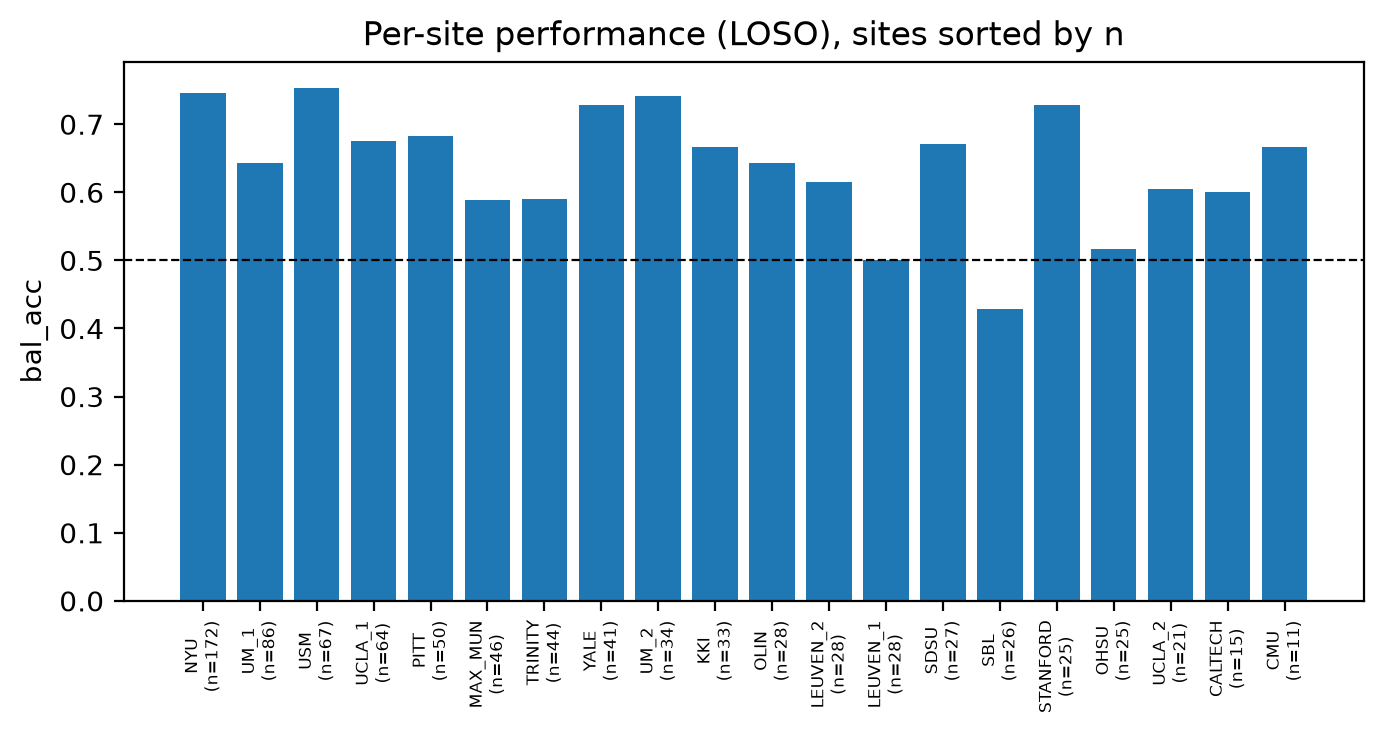

### svm  (underpowered: ['CALTECH', 'CMU'])

,n,n_pos,bal_acc,auc
site,,,,
NYU,172,74,0.540,0.683
UM_1,86,34,0.574,0.643
USM,67,43,0.593,0.761
UCLA_1,64,37,0.571,0.646
PITT,50,24,0.566,0.638
MAX_MUN,46,19,0.553,0.507
TRINITY,44,19,0.638,0.598
YALE,41,22,0.633,0.656
UM_2,34,13,0.568,0.762


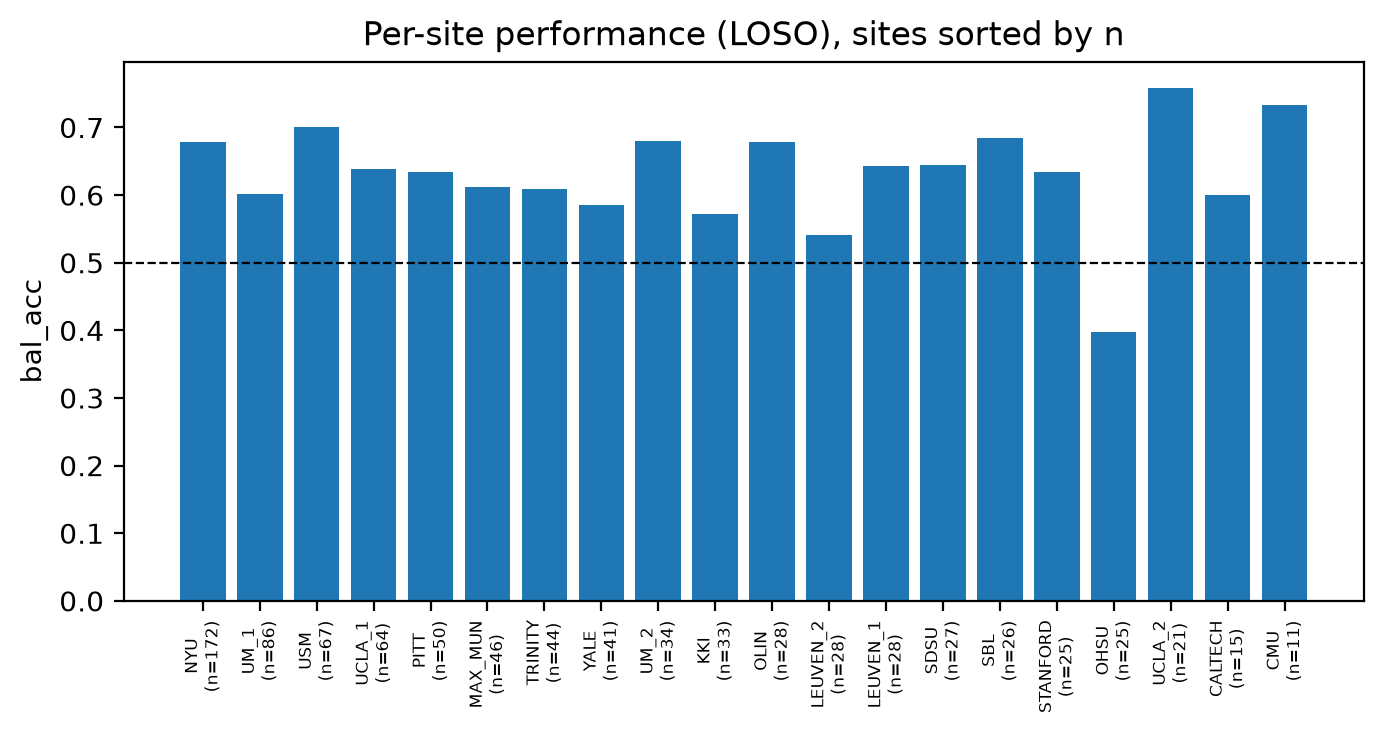

### pop_cheb  (underpowered: ['CALTECH', 'CMU'])

,n,n_pos,bal_acc,auc
site,,,,
NYU,172,74,0.657,0.706
UM_1,86,34,0.612,0.669
USM,67,43,0.500,0.548
UCLA_1,64,37,0.500,0.694
PITT,50,24,0.500,0.715
MAX_MUN,46,19,0.473,0.507
TRINITY,44,19,0.500,0.598
YALE,41,22,0.500,0.554
UM_2,34,13,0.674,0.707


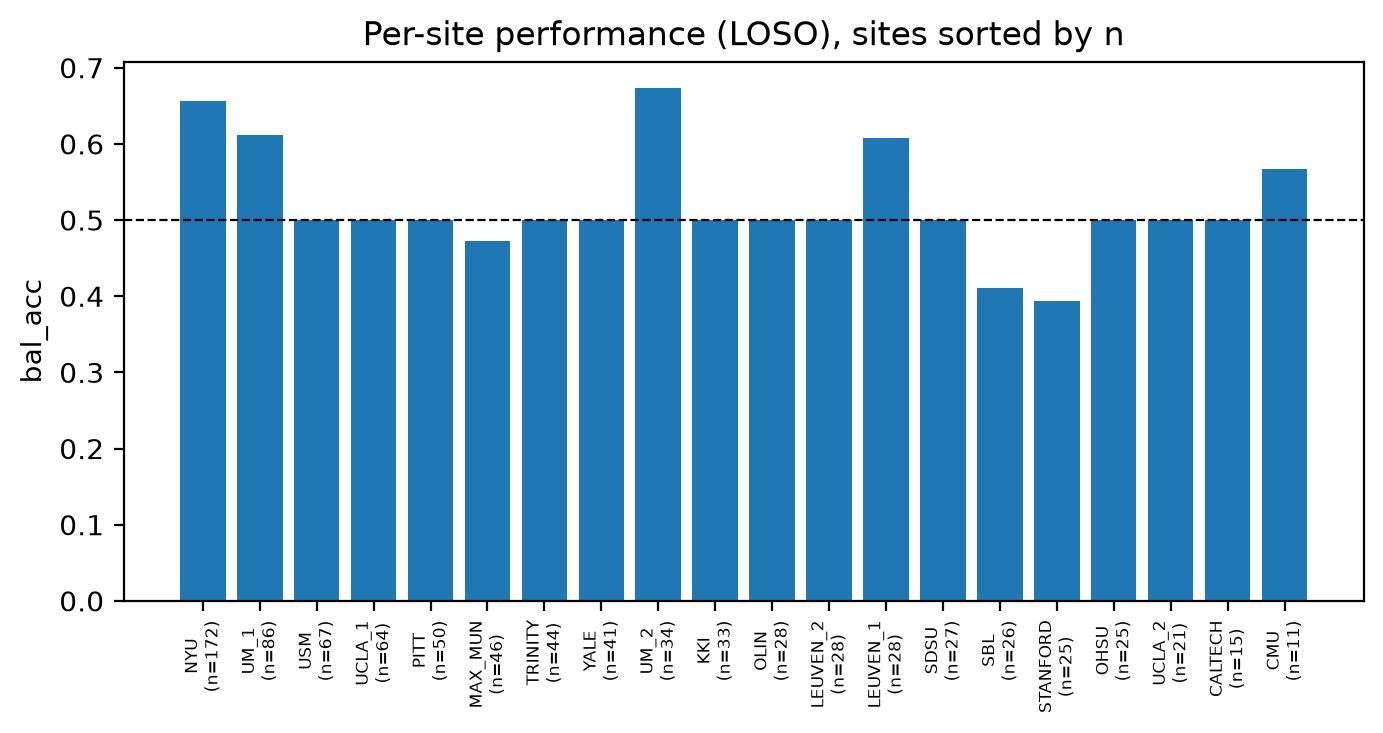

### rf  (underpowered: ['CALTECH', 'CMU'])

,n,n_pos,bal_acc,auc
site,,,,
NYU,172,74,0.627,0.709
UM_1,86,34,0.648,0.686
USM,67,43,0.688,0.751
UCLA_1,64,37,0.661,0.747
PITT,50,24,0.647,0.751
MAX_MUN,46,19,0.533,0.562
TRINITY,44,19,0.636,0.658
YALE,41,22,0.739,0.751
UM_2,34,13,0.723,0.681


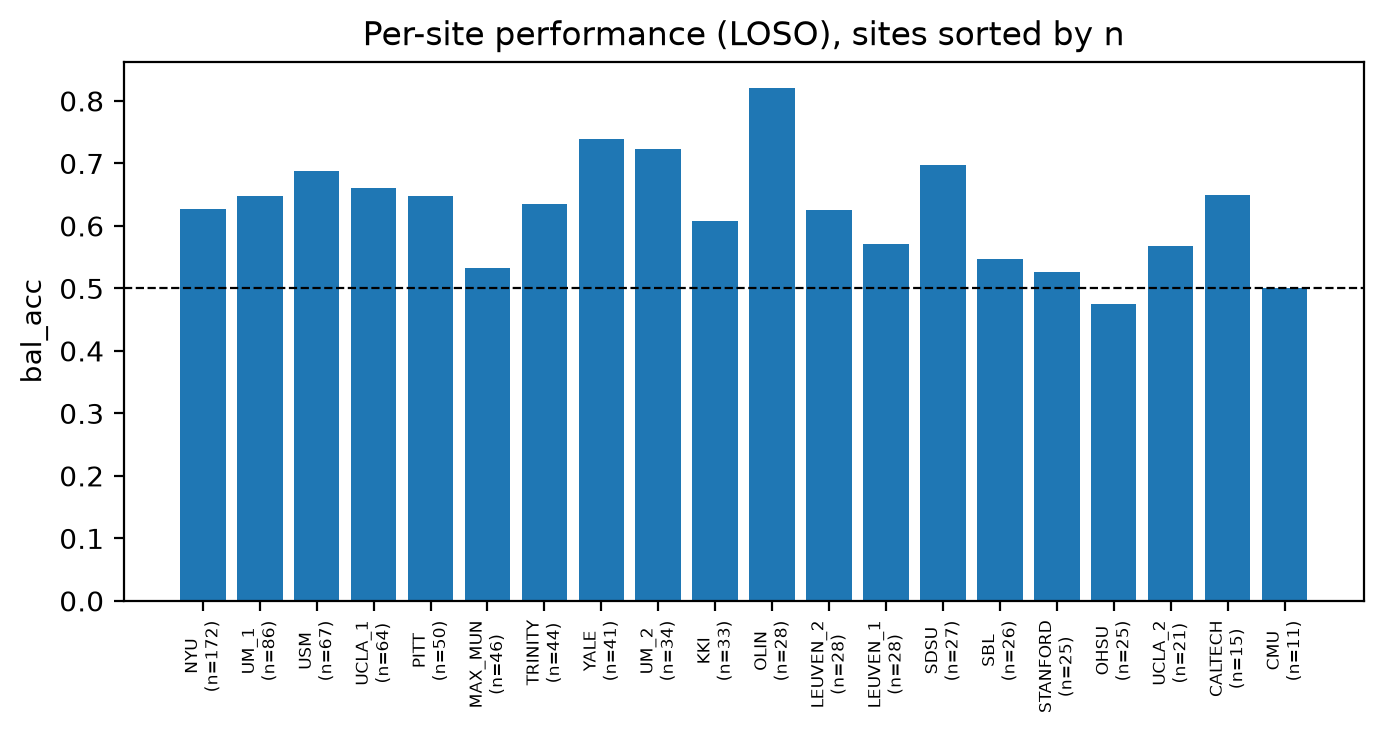

### mlp_graph  (underpowered: ['CALTECH', 'CMU'])

,n,n_pos,bal_acc,auc
site,,,,
NYU,172,74,0.504,0.527
UM_1,86,34,0.515,0.532
USM,67,43,0.523,0.521
UCLA_1,64,37,0.502,0.563
PITT,50,24,0.452,0.479
MAX_MUN,46,19,0.534,0.532
TRINITY,44,19,0.500,0.469
YALE,41,22,0.566,0.600
UM_2,34,13,0.500,0.557


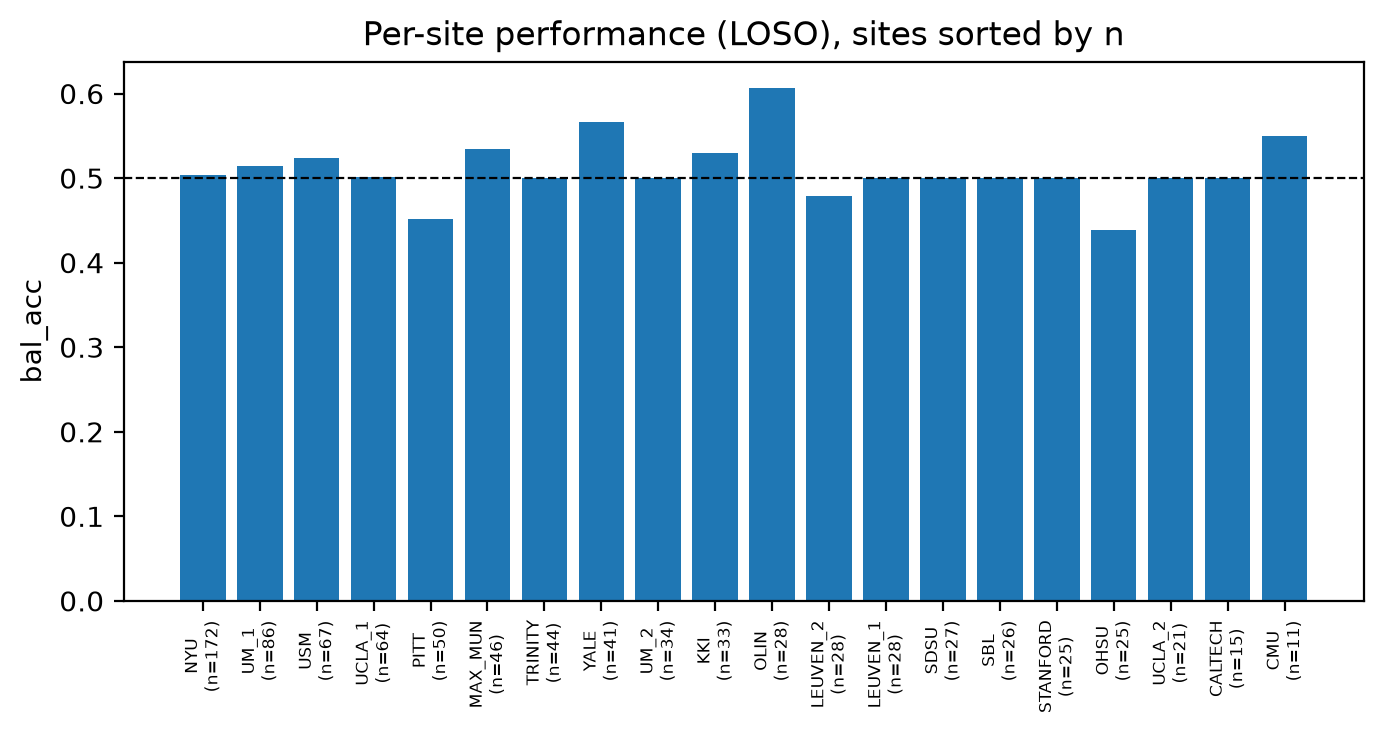

### gin  (underpowered: ['CALTECH', 'CMU'])

,n,n_pos,bal_acc,auc
site,,,,
NYU,172,74,0.591,0.612
UM_1,86,34,0.569,0.605
USM,67,43,0.570,0.668
UCLA_1,64,37,0.521,0.577
PITT,50,24,0.593,0.595
MAX_MUN,46,19,0.512,0.548
TRINITY,44,19,0.521,0.594
YALE,41,22,0.542,0.677
UM_2,34,13,0.498,0.601


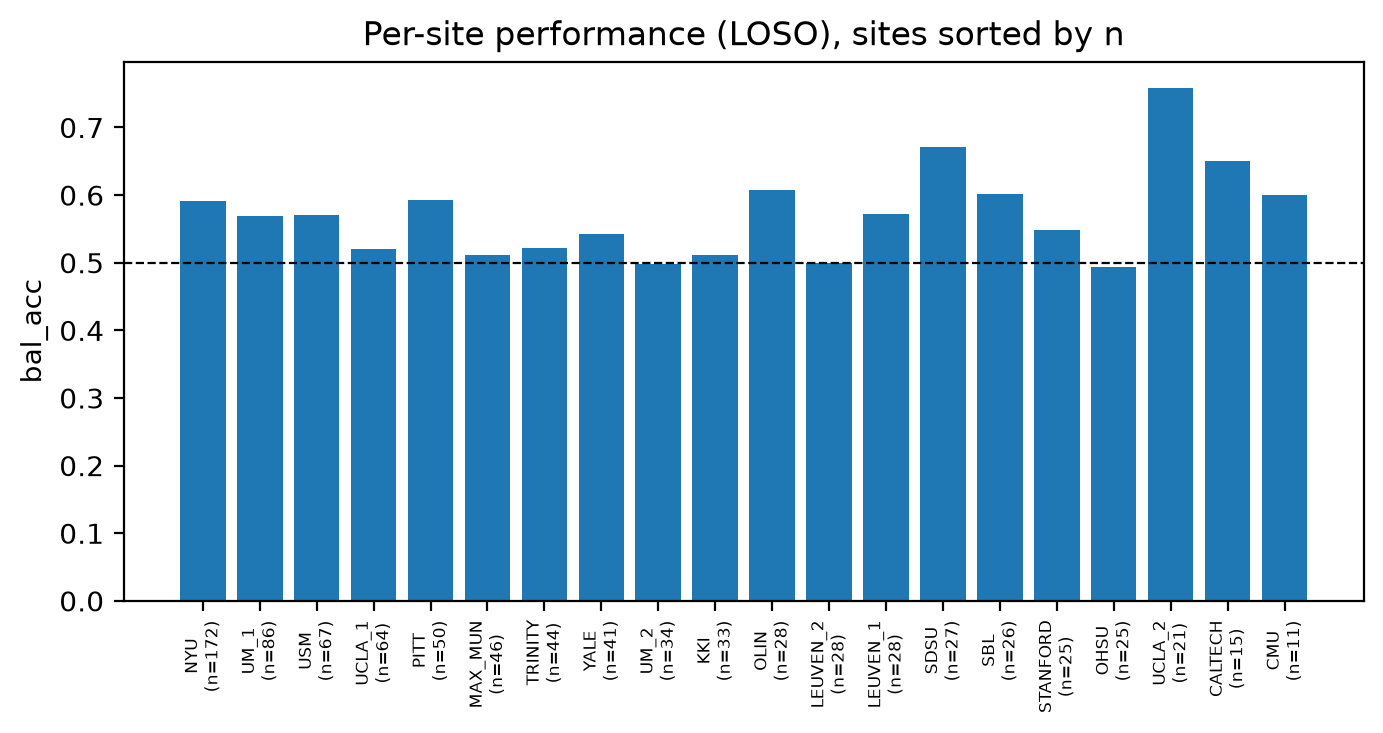

### hybrid  (underpowered: none)

,n,n_pos,bal_acc,auc
site,,,,
NYU,172,74,0.639,0.723
UM_1,86,34,0.554,0.656
USM,67,43,0.577,0.645
UCLA_1,64,37,0.577,0.667
PITT,50,24,0.431,0.497
MAX_MUN,46,19,0.649,0.659
TRINITY,44,19,0.582,0.613
YALE,41,22,0.648,0.622
UM_2,34,13,0.593,0.597


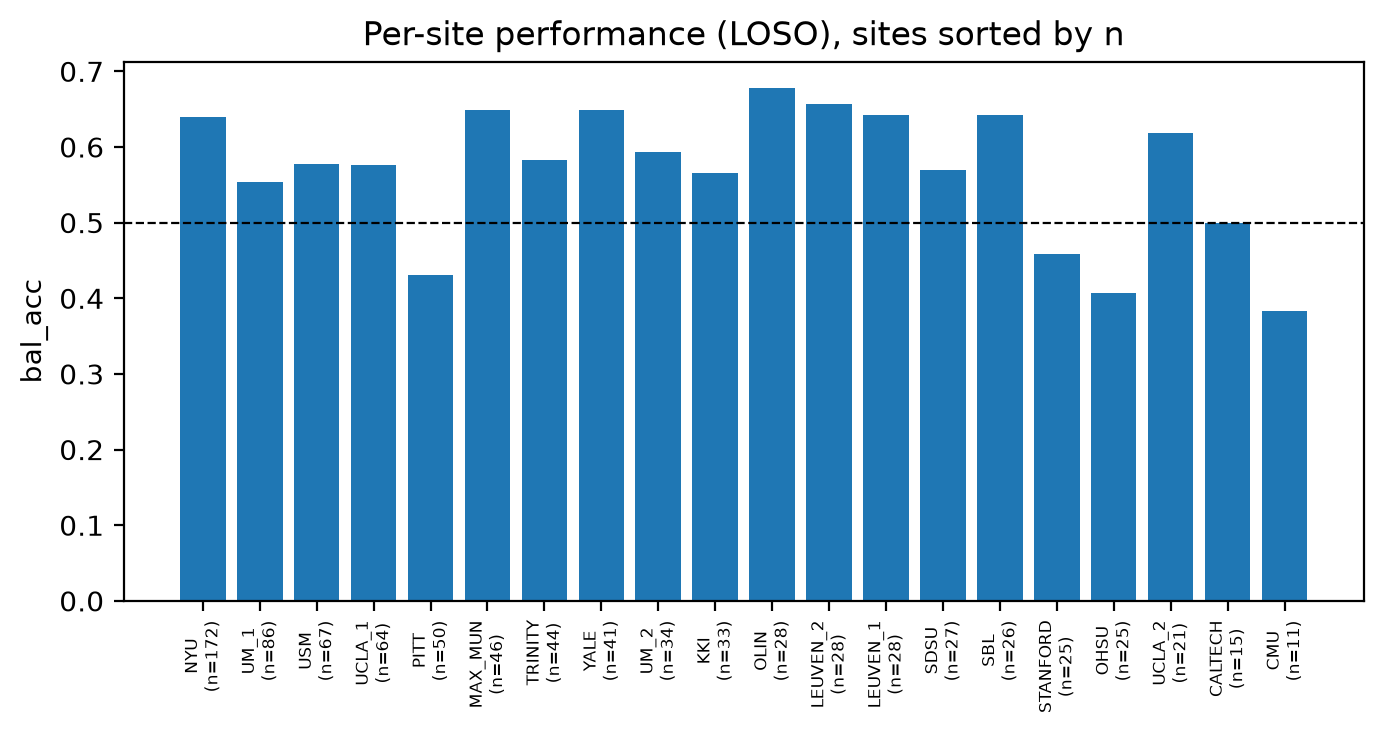

### svm  (underpowered: ['CALTECH', 'CMU'])

,n,n_pos,bal_acc,auc
site,,,,
NYU,172,74,0.552,0.679
UM_1,86,34,0.564,0.646
USM,67,43,0.605,0.774
UCLA_1,64,37,0.598,0.642
PITT,50,24,0.566,0.615
MAX_MUN,46,19,0.553,0.511
TRINITY,44,19,0.585,0.606
YALE,41,22,0.656,0.670
UM_2,34,13,0.505,0.773


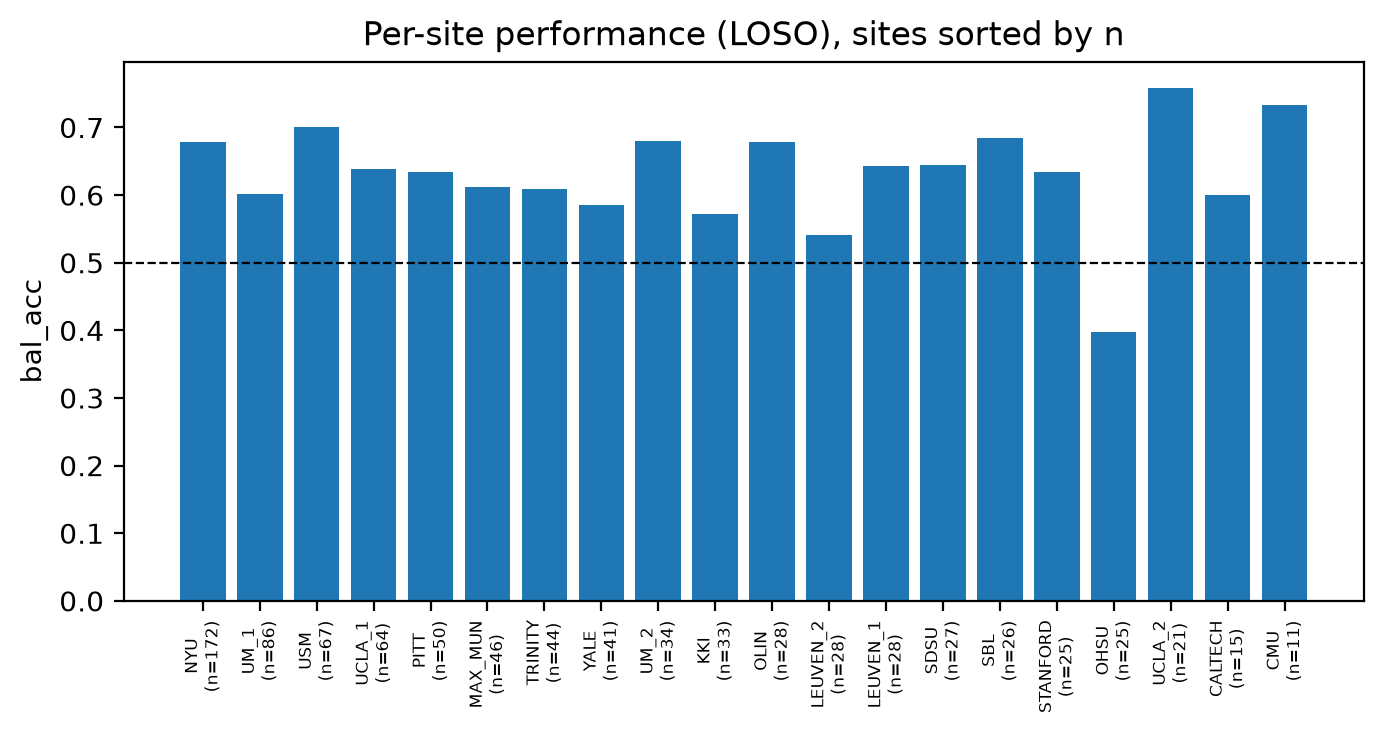

### svm  (underpowered: ['CALTECH', 'CMU'])

,n,n_pos,bal_acc,auc
site,,,,
NYU,172,74,0.627,0.622
UM_1,86,34,0.641,0.659
USM,67,43,0.603,0.608
UCLA_1,64,37,0.654,0.709
PITT,50,24,0.554,0.599
MAX_MUN,46,19,0.515,0.431
TRINITY,44,19,0.509,0.522
YALE,41,22,0.664,0.754
UM_2,34,13,0.679,0.641


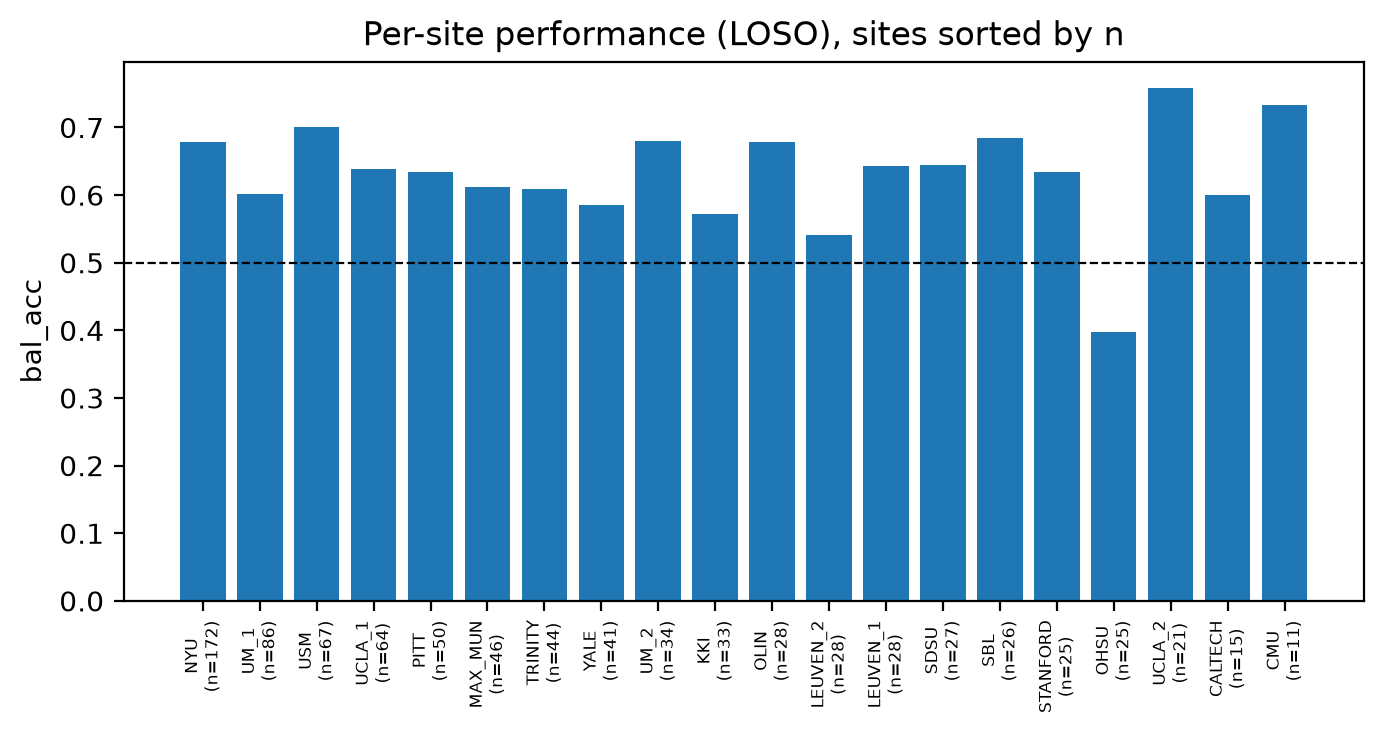

### svm  (underpowered: ['CALTECH', 'CMU'])

,n,n_pos,bal_acc,auc
site,,,,
NYU,172,74,0.666,0.735
UM_1,86,34,0.636,0.695
USM,67,43,0.594,0.698
UCLA_1,64,37,0.651,0.750
PITT,50,24,0.635,0.721
MAX_MUN,46,19,0.567,0.495
TRINITY,44,19,0.489,0.488
YALE,41,22,0.762,0.842
UM_2,34,13,0.597,0.718


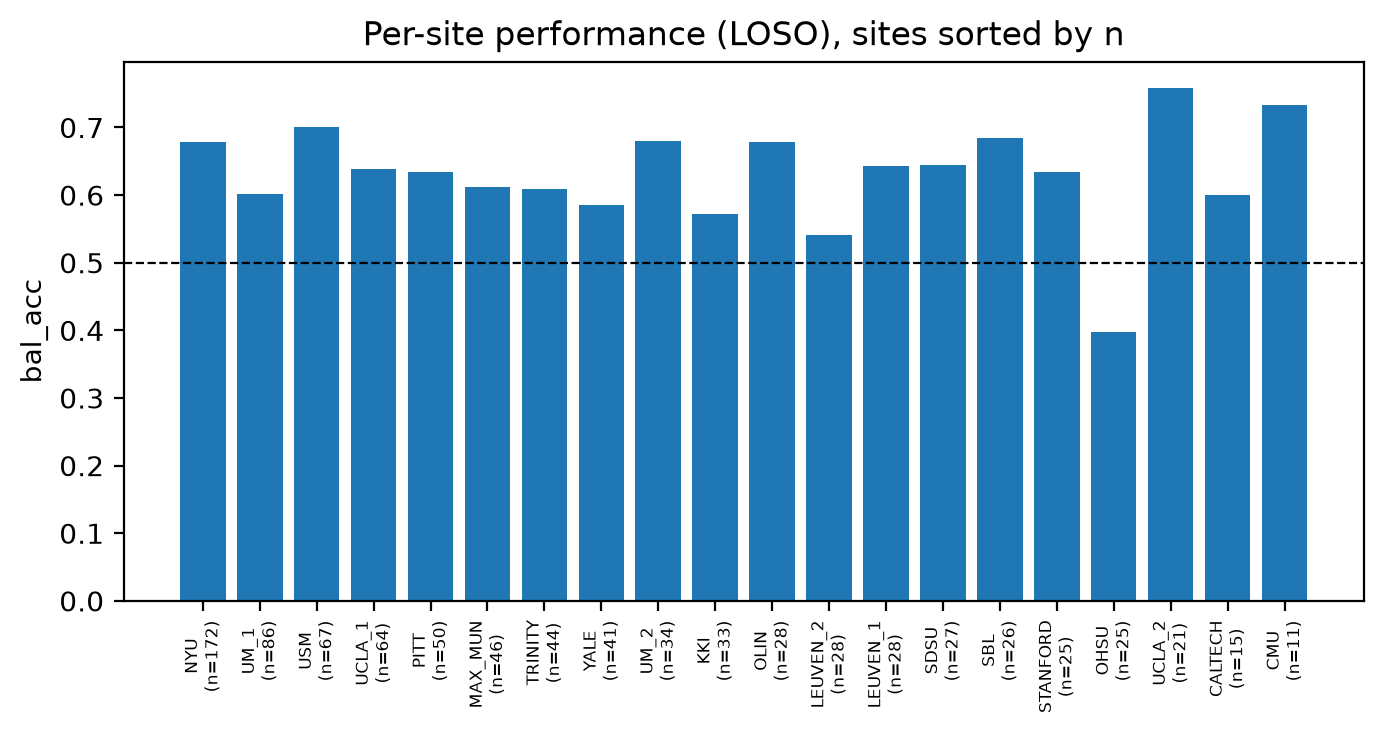

### mlp  (underpowered: ['CALTECH', 'CMU'])

,n,n_pos,bal_acc,auc
site,,,,
NYU,172,74,0.722,0.760
UM_1,86,34,0.670,0.736
USM,67,43,0.733,0.836
UCLA_1,64,37,0.708,0.741
PITT,50,24,0.614,0.696
MAX_MUN,46,19,0.559,0.569
TRINITY,44,19,0.523,0.568
YALE,41,22,0.660,0.756
UM_2,34,13,0.751,0.813


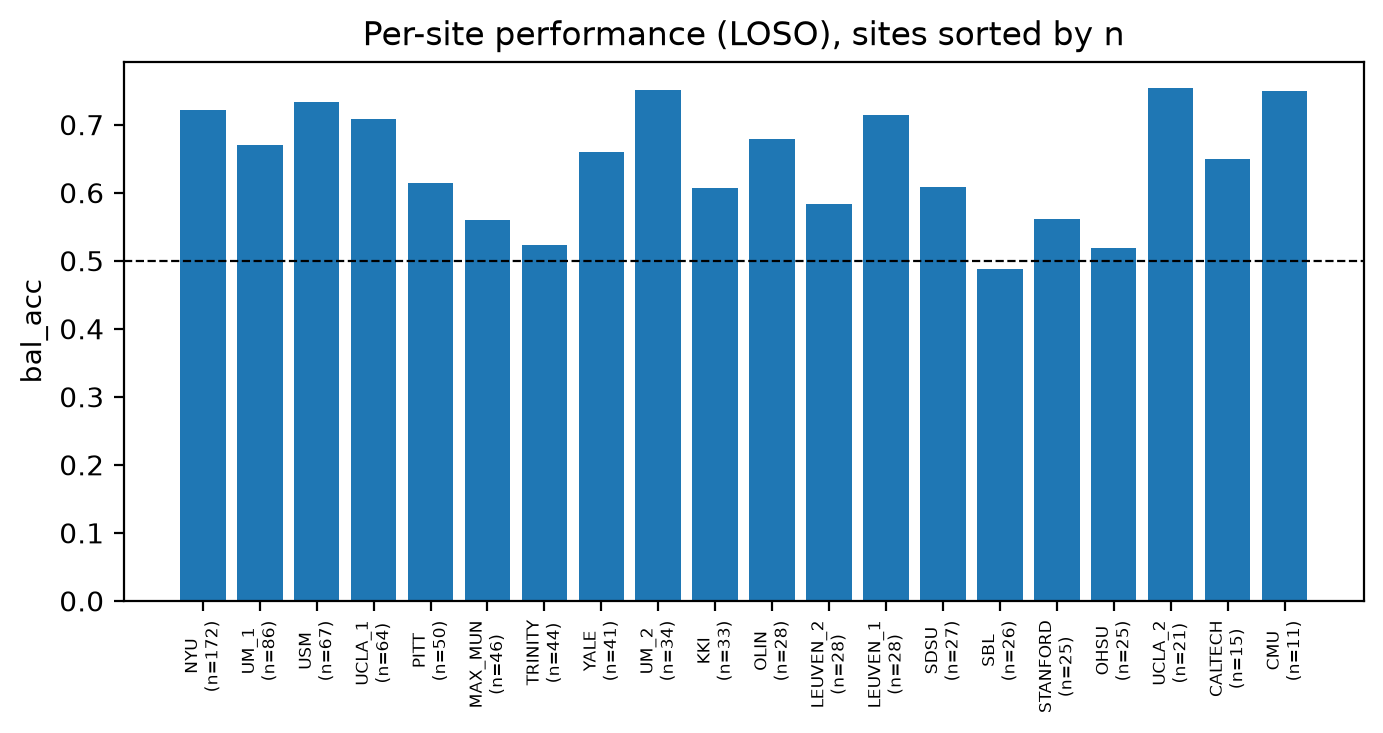

In [7]:
loso = [b for b in blobs if b["protocol"] == "loso"]
for b in loso:
    rows = [{"site": f["fold"], "n": f["metrics"]["n_test"], "n_pos": f["metrics"]["n_pos"],
             "bal_acc": f["metrics"]["bal_acc"], "auc": f["metrics"]["auc"]}
            for f in b["folds"]]
    t = pd.DataFrame(rows).sort_values("n", ascending=False).set_index("site")
    display(Markdown(f"### {b['model']}  (underpowered: {b['underpowered_folds'] or 'none'})"))
    display(t.round(3))
    show_fig(f"per_site_{b['model']}.png")

## 6. ROC and precision-recall curves

Pooled across folds. Pooling is the right way to draw a single curve when individual
LOSO folds are small — a per-fold AUC on a 12-subject site is not interpretable.

**ROC — kfold**

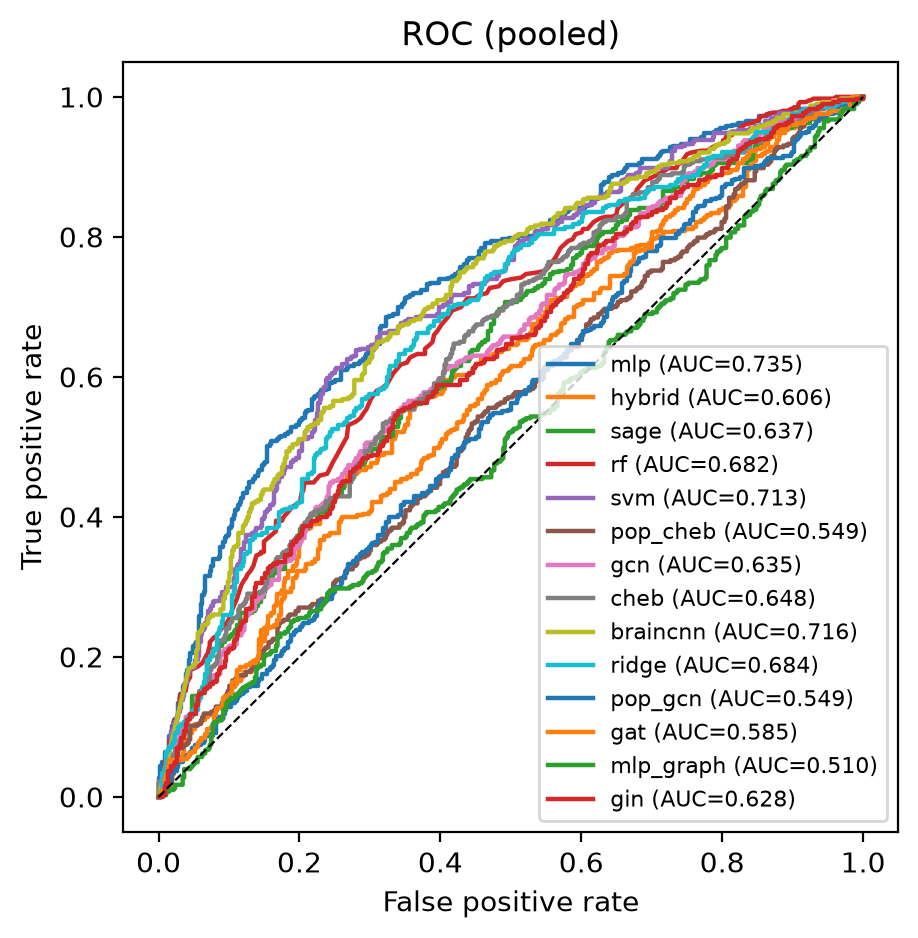

**Precision-recall — kfold**

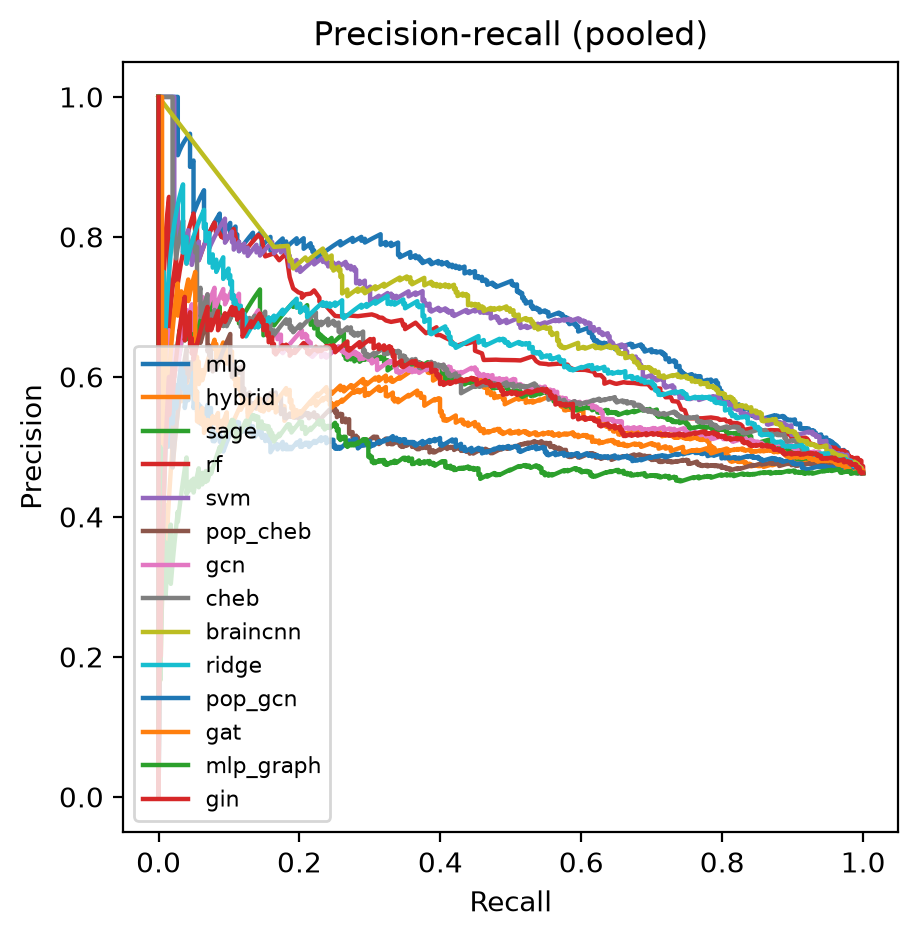

**ROC — loso**

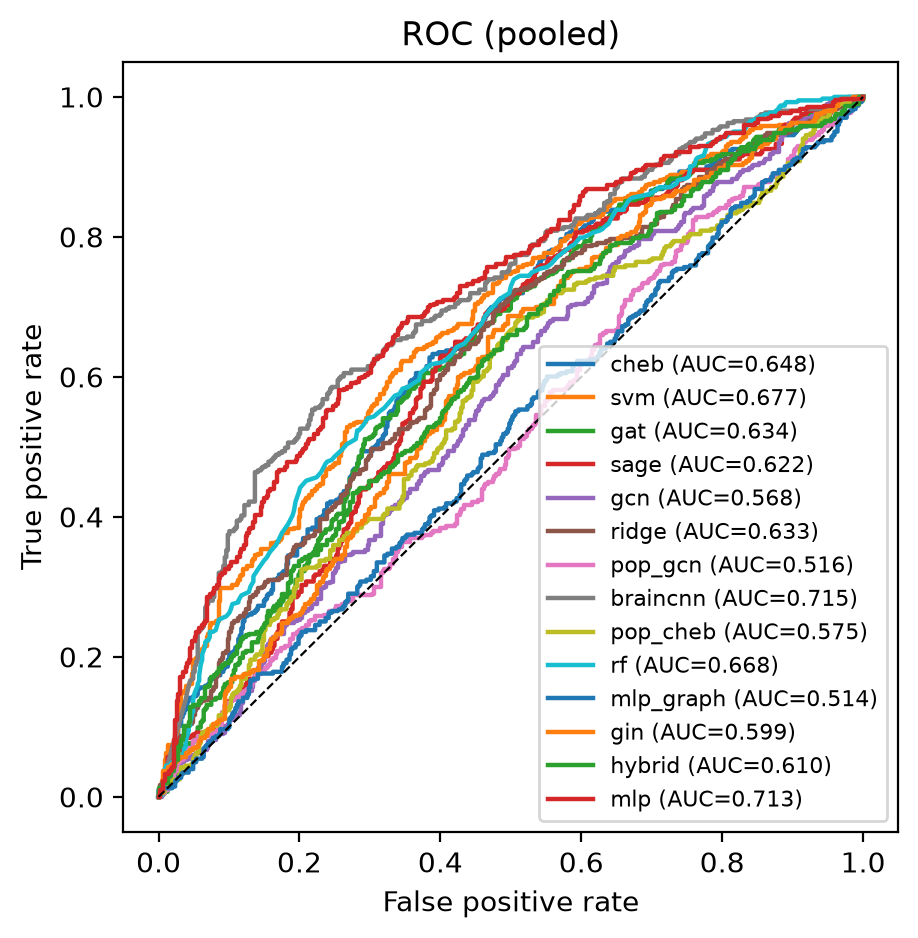

**Precision-recall — loso**

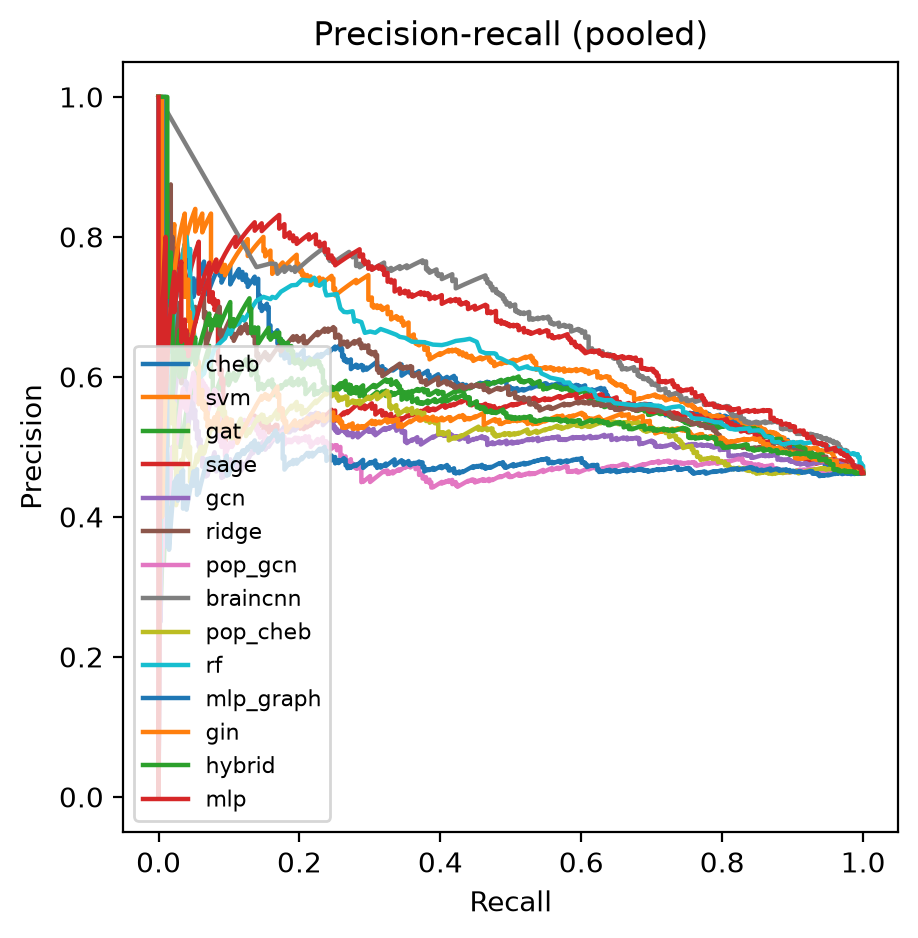

In [8]:
for protocol in sorted(df["protocol"].dropna().unique()):
    show_fig(f"roc_{protocol}.png", f"ROC — {protocol}")
    show_fig(f"pr_{protocol}.png", f"Precision-recall — {protocol}")

## 7. Statistical comparisons

Two tests, because they answer different questions:

- **DeLong** compares two ROC curves on the *same subjects*. This is possible only
  because every run saves per-fold predicted probabilities against a shared split file.
- **Nadeau–Bengio corrected resampled t-test** compares fold scores from repeated k-fold.
  A plain paired t-test is anti-conservative here because folds share training data.

Both are reported with Holm–Bonferroni correction across the family of comparisons.

In [9]:
for protocol in sorted(df["protocol"].dropna().unique()):
    stats = load_json(TABLES / f"stats_{protocol}.json", {})
    if not stats.get("delong"):
        continue
    display(Markdown(f"### {protocol} — DeLong (paired, pooled predictions)"))
    d = pd.DataFrame(stats["delong"]).T
    if "delong_holm" in stats:
        d["p_adj"] = pd.DataFrame(stats["delong_holm"]).T["p_adj"]
        d["significant"] = pd.DataFrame(stats["delong_holm"]).T["significant"]
    display(d.round(4))

    if stats.get("corrected_ttest"):
        display(Markdown(f"### {protocol} — corrected resampled t-test (balanced accuracy)"))
        display(pd.DataFrame(stats["corrected_ttest"]).T.round(4))

### kfold — DeLong (paired, pooled predictions)

,auc_a,auc_b,delta,z,p,n_paired_subjects,p_adj,significant
braincnn_vs_cheb,0.7158,0.6484,0.0674,3.2305,0.0012,871.0,0.054379,False
braincnn_vs_gat,0.7158,0.5848,0.1310,6.2002,0.0000,871.0,0.0,True
braincnn_vs_gcn,0.7158,0.6347,0.0811,4.0247,0.0001,871.0,0.003481,True
braincnn_vs_gin,0.7158,0.6276,0.0882,4.0109,0.0001,871.0,0.003629,True
braincnn_vs_hybrid,0.7158,0.6056,0.1102,5.2308,0.0000,871.0,0.000012,True
...,...,...,...,...,...,...,...,...
rf_vs_sage,0.6816,0.6375,0.0442,2.1712,0.0299,871.0,0.877802,False
rf_vs_svm,0.6816,0.7133,-0.0317,-1.6070,0.1081,871.0,1.0,False
ridge_vs_sage,0.6842,0.6375,0.0468,2.0432,0.0410,871.0,1.0,False
ridge_vs_svm,0.6842,0.7133,-0.0291,-2.8622,0.0042,871.0,0.159892,False


### kfold — corrected resampled t-test (balanced accuracy)

,mean_diff,t,p,df
braincnn_vs_cheb,0.0609,1.2418,0.2457,9.0
braincnn_vs_gat,0.1058,3.9205,0.0035,9.0
braincnn_vs_gcn,0.0581,1.3629,0.2060,9.0
braincnn_vs_gin,0.0768,1.8182,0.1024,9.0
braincnn_vs_mlp,-0.0081,-0.2655,0.7966,9.0
...,...,...,...,...
rf_vs_sage,0.0259,0.7281,0.4850,9.0
rf_vs_svm,-0.0520,-2.1867,0.0566,9.0
ridge_vs_sage,0.0456,1.0006,0.3432,9.0
ridge_vs_svm,-0.0323,-1.6954,0.1242,9.0


### loso — DeLong (paired, pooled predictions)

,auc_a,auc_b,delta,z,p,n_paired_subjects,p_adj,significant
braincnn_vs_cheb,0.7149,0.6484,0.0665,3.2998,0.0010,871.0,0.048375,True
braincnn_vs_gat,0.7149,0.6345,0.0804,4.0637,0.0000,871.0,0.002801,True
braincnn_vs_gcn,0.7149,0.5682,0.1467,7.1105,0.0000,871.0,0.0,True
braincnn_vs_gin,0.7149,0.5995,0.1154,5.3071,0.0000,871.0,0.000008,True
braincnn_vs_hybrid,0.7149,0.6096,0.1053,5.1427,0.0000,871.0,0.00002,True
...,...,...,...,...,...,...,...,...
rf_vs_sage,0.6675,0.6224,0.0451,2.2517,0.0243,871.0,0.779009,False
rf_vs_svm,0.6675,0.6769,-0.0094,-0.4916,0.6230,871.0,1.0,False
ridge_vs_sage,0.6326,0.6224,0.0102,0.4504,0.6525,871.0,1.0,False
ridge_vs_svm,0.6326,0.6769,-0.0442,-4.3221,0.0000,871.0,0.000958,True


### loso — corrected resampled t-test (balanced accuracy)

,mean_diff,t,p,df
braincnn_vs_cheb,0.0462,1.5872,0.1290,19.0
braincnn_vs_gat,0.0585,1.8956,0.0733,19.0
braincnn_vs_gcn,0.0792,2.4411,0.0246,19.0
braincnn_vs_gin,0.0678,1.8728,0.0766,19.0
braincnn_vs_hybrid,0.0707,1.7047,0.1045,19.0
...,...,...,...,...
rf_vs_sage,0.0348,1.1040,0.2834,19.0
rf_vs_svm,-0.0068,-0.2055,0.8394,19.0
ridge_vs_sage,-0.0011,-0.0483,0.9620,19.0
ridge_vs_svm,-0.0426,-1.7693,0.0929,19.0


## 8. Explainability

Report **stability across folds, not just the mean**. An ROI that ranks #1 in three folds
and #150 in the other seven is noise, and it is the first thing a reviewer will ask
about. `explain/saliency.py::rank_stability` produces the selection frequency shown
here; anything below ~0.8 should not be named in the paper's text.

,rank,roi_idx,name,score,std_across_folds,in_top_k_fraction
0,1,5,CC200_005,2.8859,0.0780,1.0
1,2,103,CC200_103,2.8238,0.0927,1.0
2,3,67,CC200_067,2.7985,0.0850,1.0
3,4,175,CC200_175,2.6801,0.0906,1.0
4,5,55,CC200_055,2.6588,0.0145,1.0
5,6,11,CC200_011,2.6582,0.0817,1.0
6,7,127,CC200_127,2.6543,0.0929,1.0
7,8,163,CC200_163,2.6430,0.0871,1.0
8,9,155,CC200_155,2.6346,0.0433,1.0
9,10,107,CC200_107,2.5822,0.1189,1.0


Method: **attention** on **gat**, 5 folds.  Mean pairwise Spearman across folds: **0.961**  ·  **18** ROIs enter the top-20 in at least 80% of folds.

**Top ROIs with across-fold error bars**

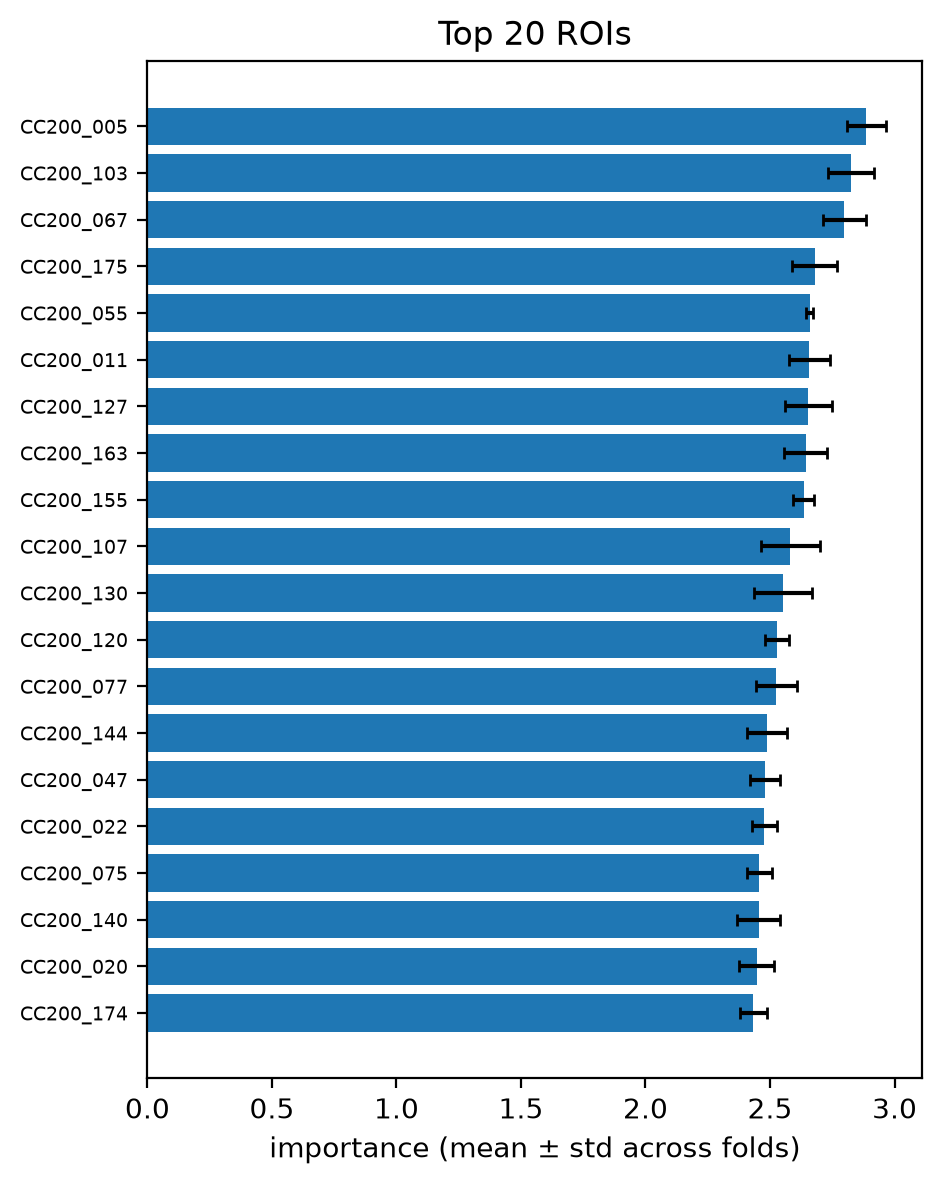

**Saliency stability**

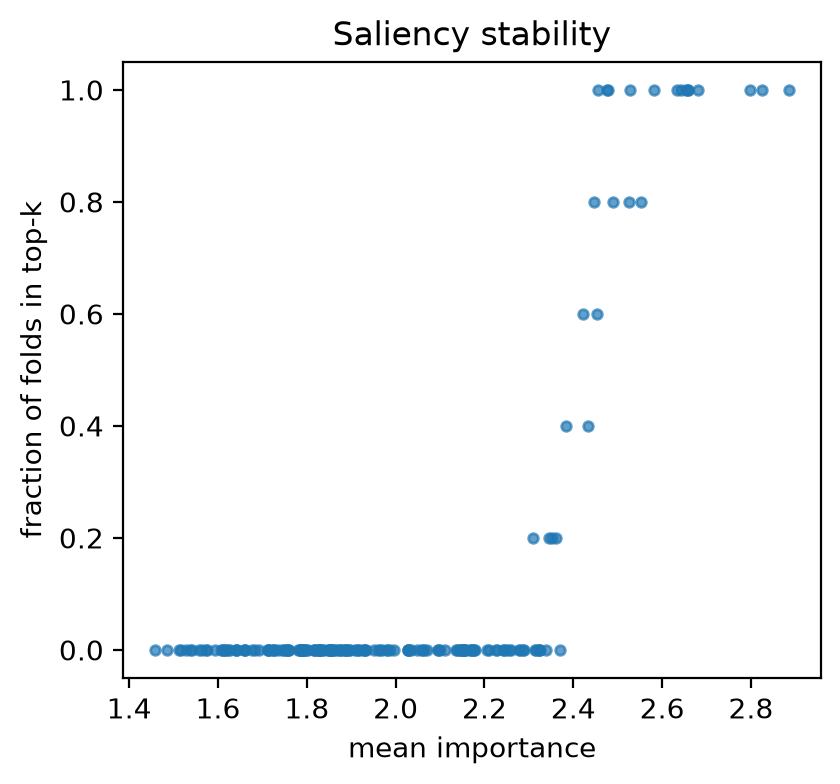

In [10]:
expl = load_json(ROOT / "results/explain/roi_importance.json", {})
if expl:
    t = pd.DataFrame(expl["top_rois"])
    display(t.round(4))
    rho = expl.get("mean_pairwise_spearman")
    n_stable = len(expl.get("stable_rois", []))
    display(Markdown(
        f"Method: **{expl['method']}** on **{expl['model']}**, {expl['n_folds']} folds.  "
        f"Mean pairwise Spearman across folds: **{rho:.3f}**  ·  "
        f"**{n_stable}** ROIs enter the top-{len(t)} in at least 80% of folds."
    ))
    if rho is not None and rho < 0.3:
        display(Markdown(
            "> **The ranking is not reproducible across folds.** Report it as unstable "
            "rather than naming individual regions in the text."
        ))
    show_fig("top_rois.png", "Top ROIs with across-fold error bars")
    show_fig("roi_stability.png", "Saliency stability")
else:
    display(Markdown(
        "_no explainability artifacts yet — these are produced at M14, after a trained "
        "GAT exists. See `explain/saliency.py`._"
    ))

## 8b. Hybrid model — stage-wise attribution

The hybrid is built in stages so that a failure is attributable to one half: the encoder
alone, then the population GNN on frozen embeddings, then optionally end-to-end with the
gradient-reversal site head. If stage 3 does not beat stage 1, the population graph is
adding nothing and the extra complexity is not earning its place in the paper.

In [11]:
hybrid = [b for b in blobs if b.get("model") == "hybrid"]
if hybrid:
    rows = []
    for b in hybrid:
        row = {"protocol": b["protocol"],
               "stage1_encoder": b["stage1_aggregate"]["bal_acc_mean"],
               "stage3_population": b["stage3_aggregate"]["bal_acc_mean"],
               "reported": b["aggregate"]["bal_acc_mean"],
               "lambda_adv": b["config"].get("lambda_adv"),
               "end_to_end": b["config"].get("end_to_end")}
        row["stage3_gain"] = row["stage3_population"] - row["stage1_encoder"]
        rows.append(row)
    display(pd.DataFrame(rows).round(3))
    display(Markdown(
        "`stage3_gain` is the honest measure of what the population graph contributes on "
        "top of the encoder. A gain near zero or negative is a reportable negative "
        "result, not a reason to keep tuning until it turns positive."
    ))
    iso = [f.get("n_isolated", 0) for b in hybrid for f in b["folds"]]
    if any(iso):
        display(Markdown(
            f"Up to **{max(iso)}** nodes were isolated in the population graph. Under "
            "LOSO with a site affinity term this is the expected disconnection "
            "behaviour — report it, do not hide it."
        ))
else:
    display(Markdown("_no hybrid runs yet — `make hybrid`_"))

,protocol,stage1_encoder,stage3_population,reported,lambda_adv,end_to_end,stage3_gain
0,kfold,0.585,0.598,0.598,0.0,False,0.012
1,loso,0.538,0.569,0.569,0.0,False,0.031


`stage3_gain` is the honest measure of what the population graph contributes on top of the encoder. A gain near zero or negative is a reportable negative result, not a reason to keep tuning until it turns positive.

## 9. Before believing any of this

- [ ] `make leak` green — the leakage suite, not just the general test run
- [ ] label shuffle at chance in section 2
- [ ] single-batch overfit reaches 100% (`tests/test_models.py`)
- [ ] mean node degree in the 10–40 range for CC200 — a dense graph makes message
      passing a global average, and it is the cause of a GNN stuck near 53% about 40%
      of the time
- [ ] every reported model has ≥3 seeds; a model that beats a baseline on one seed is
      not a result
- [ ] every number traceable to a `results/runs/*.json` with a git commit hash
- [ ] the k-fold → LOSO drop is reported, not buried
- [ ] saliency stability reported alongside the top-ROI list, not instead of it
- [ ] for the hybrid, stage 1 and stage 3 scores both reported, not just the best one
- [ ] statistical comparisons paired on **subject id**, and any refused comparison
      surfaced in `stats_*.json["skipped"]` rather than silently dropped

In [12]:
checks = pd.DataFrame([
    {"run_id": b["run_id"], "model": b["model"], "protocol": b["protocol"],
     "git_commit": b.get("git_commit"), "n_folds": b["aggregate"]["n_folds"],
     "probs_saved": all("y_prob" in f for f in b["folds"]),
     "sub_ids_saved": all("sub_ids" in f for f in b["folds"]),
     "runtime_sec": b.get("runtime_sec")}
    for b in blobs
])
display(checks)
assert checks["probs_saved"].all(), "a run is missing per-fold probabilities — DeLong is impossible"
assert checks["sub_ids_saved"].all(), "a run is missing sub_ids — paired tests cannot align subjects"
print("provenance OK: every run carries a config, a commit, per-fold probabilities and subject ids")

,run_id,model,protocol,git_commit,n_folds,probs_saved,sub_ids_saved,runtime_sec
0,18817025fc5c_0,cheb,loso,unknown,20,True,True,2286.7
1,1d44813524a5_0,svm,loso,unknown,20,True,True,28.6
2,1e042ffd599d_0,mlp,kfold,unknown,10,True,True,57.5
3,2076bae63db9_0,gat,loso,unknown,20,True,True,2642.0
4,228cdaea9da9_0,svm,loso,unknown,20,True,True,32.9
5,37b786d985c1_0,sage,loso,unknown,20,True,True,987.5
6,3a4ff8ca0dfd_0,hybrid,kfold,unknown,5,True,True,340.3
7,45933eb39267_0,gcn,loso,unknown,20,True,True,1352.5
8,570dbc70c2c9_0,ridge,loso,unknown,20,True,True,16.3
9,5ce3eeff6171_0,sage,kfold,unknown,10,True,True,414.0


provenance OK: every run carries a config, a commit, per-fold probabilities and subject ids
